
# Codex MCP + Oracle AI Database

This notebook builds a practical Codex CLI workflow around **SQLcl MCP Server**, **Oracle AI Database**, Oracle AI Agent Memory, and optional **LangChain** orchestration.

The architecture separates four responsibilities:

- **Codex CLI** acts as the MCP client and AI agent interface.
- **SQLcl MCP Server** exposes Oracle AI Database operations through an explicit MCP tool contract.
- **Oracle AI Database** stores durable system memory: conversation history, tool traces, retrieval data, and validation checks.
- **LangChain** can wrap retrieval and memory assembly when an application needs repeatable orchestration.

The notebook does not call Codex from Python. In the local Codex CLI + SQLcl MCP pattern, Codex CLI runs the agent experience and spawns SQLcl as a local MCP server process. Python is used here to build and validate the Oracle AI Database memory layer, so the same workflow is inspectable, repeatable, and ready to plug into Codex CLI.


## Architecture at a Glance

```text
                         +--------------------------+
                         |      Human operator      |
                         +------------+-------------+
                                      | asks / reviews
                                      v
+------------------------------------------------------------------+
|                         Codex CLI                                |
|  Intent, planning, conversation continuity, MCP client behavior  |
+------------+---------------------------------------+-------------+
             | Loop A: explicit MCP tool call        | grounded context
             v                                       |
+--------------------------+                         |
|     SQLcl MCP Server     |                         |
|        `sql -mcp`        |                         |
|  saved SQLcl connection  |                         |
+------------+-------------+                         |
             | SQL execution through declared tools  |
             v                                       |
+----------------------------------------------------+-------------+           +------------------------------+        
|                      Oracle AI Database                           |   < ---  |   Oracle AI Agent Memory     |
|  privileges  |  SQL/JSON memory  |  Oracle Text  |  VECTOR search |          |     (Python package)         |
+------------+---------------------------------------+-------------+           +------------------------------+
             | Loop B: durable memory + retrieval    |
             v                                       v
+--------------------------+           +--------------------------+
| Conversation + tool logs |           |   Retrieval evidence     |
| MCP traces, status,      |           |   lexical + vector +     |
| errors, tenant metadata  |           |   metadata filtering     |
+--------------------------+           +------------+-------------+
                                                   | optional wrapper
                                                   v
                                      +--------------------------+
                                      |        LangChain         |
                                      | retrieval orchestration  |
                                      +--------------------------+
```

The important boundary is MCP: Codex CLI does not receive implicit database access. It receives a declared SQLcl MCP tool surface, while Oracle AI Database remains responsible for data access, privileges, durable memory, and retrieval.

This notebook validates the Oracle AI Database memory and retrieval layer directly, then prepares the artifacts needed for live Codex MCP validation: the MCP config preview, the SQLcl saved-connection check, and the manual Codex CLI test.


## What You Will Learn

- How Codex CLI uses SQLcl MCP as an explicit Oracle AI Database tool boundary.
- How to generate and validate the Codex MCP configuration artifacts.
- How to store Codex/MCP conversation traces, tool logs, and retrieval memory in Oracle AI Database.
- How to classify MCP tool calls before they are treated as safe to execute.
- How to run lexical search, vector search, and hybrid retrieval over the same memory layer.
- How to create evidence packages and LangChain-compatible documents from Oracle AI Database memory.


## Workflow Overview

1. Validate the local Codex CLI + SQLcl MCP setup path.
2. Generate the Codex `config.toml` MCP config preview.
3. Create Oracle AI Database memory tables.
4. Insert a realistic Codex + MCP workflow.
5. Inspect tool traces and controlled failures.
6. Run lexical, vector, and hybrid retrieval.
7. Visualize retrieval scores and MCP tool decisions.
8. Generate Codex-ready evidence and prompt artifacts.
9. Wrap retrieval with LangChain.
10. End with a compact validation snapshot.


## Prerequisites

You should have:

- Python 3.10+
- Oracle AI Database access
- `oracledb`, `python-dotenv`, `pandas`, `numpy`, and `matplotlib` packages installed
- Oracle SQLcl 25.2+ for SQLcl MCP workflows
- Oracle JRE 17 or 21 for SQLcl MCP workflows
- Codex CLI if you want to use the generated MCP configuration outside this notebook
- A saved SQLcl connection for MCP usage, ideally created with `-savepwd`

Optional integration packages:
- `oracleagentmemory` package (Step 15 - Oracle AI Agent Memory)
- `langchain-core`, `langchain`, `langchain-community`, and `langchain-oracledb` packages (Step 16 - LangChain)

The install cell below installs the base packages first, then attempts the optional integration packages separately. If optional packages are unavailable, the core Oracle AI Database memory workflow can still run.

The Python part of this notebook uses the values in `.env`:

```env
ORACLE_USER=
ORACLE_PASSWORD=
ORACLE_DSN=
SQLCL_PATH=
SQLCL_CONNECTION_NAME=codex_mcp
CODEX_CONFIG_PATH=
TNS_ADMIN=
OPENAI_API_KEY=
```

`OPENAI_API_KEY` is loaded so the environment is ready for OpenAI-backed Codex workflows. The notebook demo itself uses deterministic local embeddings by default, so it does not require OpenAI API calls or model billing.

Keep `SQLCL_PATH` empty if `sql` / `sql.exe` is already available on your `PATH`.


In [1]:
# Install dependencies (safe to re-run)
import sys
import subprocess
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / ".env").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
requirements_path = PROJECT_ROOT / "requirements.txt"

base_packages = [
    "oracledb",
    "python-dotenv",
    "pandas",
    "numpy",
    "matplotlib",
    "ipykernel",
]
optional_packages = [
    "oracleagentmemory",
    "langchain",
    "langchain-core",
    "langchain-community",
    "langchain-oracledb",
]


def pip_install(packages: list[str], label: str):
    command = [sys.executable, "-m", "pip", "install", "-q", *packages]
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0 and "Read-only file system" in (result.stderr or ""):
        result = subprocess.run(command + ["--user"], capture_output=True, text=True)
    if result.returncode != 0:
        print(f"{label} installation failed. Last pip messages:")
        print((result.stderr or result.stdout)[-2000:])
    return result


base_result = pip_install(base_packages, "Base dependency")
if base_result.returncode != 0:
    raise RuntimeError("Base dependency installation failed.")

print("Base dependencies installed.")

optional_result = pip_install(optional_packages, "Optional dependency")
if optional_result.returncode != 0:
    print("Optional packages could not be installed. LangChain and Oracle AI Agent Memory sections will run in optional/fallback mode.")
else:
    print("Optional dependencies installed.")

if requirements_path.exists():
    print("requirements.txt found at:", requirements_path)


Base dependencies installed.
Optional dependencies installed.
requirements.txt found at: /Users/srinidhi/Downloads/claude_mcp_oracle_ai_database_1/requirements.txt


## Configuration

This section loads `.env`, masks sensitive values, and keeps notebook paths stable whether you launch Jupyter from the project root or from the `notebooks` folder.


In [2]:
import os
import json
import platform
from pathlib import Path
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".env").exists() and (candidate / "requirements.txt").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
ENV_PATH = PROJECT_ROOT / ".env"

load_dotenv(ENV_PATH, override=True)
print("Loaded .env from:", ENV_PATH)

CONFIG = {
    "ORACLE_USER": os.getenv("ORACLE_USER", "").strip(),
    "ORACLE_PASSWORD": os.getenv("ORACLE_PASSWORD", ""),
    "ORACLE_DSN": os.getenv("ORACLE_DSN", "").strip(),
    "SQLCL_PATH": os.getenv("SQLCL_PATH", "").strip(),
    "SQLCL_CONNECTION_NAME": os.getenv("SQLCL_CONNECTION_NAME", "codex_mcp").strip() or "codex_mcp",
    "CODEX_CONFIG_PATH": os.getenv("CODEX_CONFIG_PATH", "").strip(),
    "TNS_ADMIN": os.getenv("TNS_ADMIN", "").strip(),
    "OPENAI_API_KEY": os.getenv("OPENAI_API_KEY", "").strip(),
}

config_readiness = pd.DataFrame([
    {"setting": "Oracle AI Database credentials", "status": "READY" if CONFIG["ORACLE_USER"] and CONFIG["ORACLE_PASSWORD"] and CONFIG["ORACLE_DSN"] else "ACTION_NEEDED", "public_value": "<loaded from .env>"},
    {"setting": "SQLcl executable", "status": "CONFIGURED" if CONFIG["SQLCL_PATH"] else "AUTO_DETECT", "public_value": "<SQLCL_PATH set>" if CONFIG["SQLCL_PATH"] else "<search PATH>"},
    {"setting": "SQLcl saved connection alias", "status": "READY", "public_value": CONFIG["SQLCL_CONNECTION_NAME"]},
    {"setting": "Codex config path", "status": "DEFAULT" if not CONFIG["CODEX_CONFIG_PATH"] else "CONFIGURED", "public_value": "<default ~/.codex/config.toml>" if not CONFIG["CODEX_CONFIG_PATH"] else "<custom path set>"},
    {"setting": "TNS_ADMIN", "status": "OPTIONAL" if not CONFIG["TNS_ADMIN"] else "CONFIGURED", "public_value": "<not set>" if not CONFIG["TNS_ADMIN"] else "<configured>"},
    {"setting": "OpenAI API key", "status": "CONFIGURED" if CONFIG["OPENAI_API_KEY"] else "ACTION_NEEDED", "public_value": "<loaded from .env>"},
])

print("Configuration readiness matrix")
display(config_readiness)


Loaded .env from: /Users/srinidhi/Downloads/claude_mcp_oracle_ai_database_1/.env
Configuration readiness matrix


,setting,status,public_value
0,Oracle AI Database credentials,READY,<loaded from .env>
1,SQLcl executable,CONFIGURED,<SQLCL_PATH set>
2,SQLcl saved connection alias,READY,codex_mcp
3,Codex config path,DEFAULT,<default ~/.codex/config.toml>
4,TNS_ADMIN,OPTIONAL,<not set>
5,OpenAI API key,CONFIGURED,<loaded from .env>


## Step 1 - Validate the SQLcl MCP Environment

Codex CLI starts SQLcl as an MCP server by launching `sql -mcp`. This cell does **not** start the MCP server, because an MCP server is a long-running process. Instead, it checks whether SQLcl and Java are discoverable and captures their readiness.

If the SQLcl row says `ACTION_NEEDED`, that does not mean the Oracle AI Database memory workflow failed. It means live Codex MCP validation still needs standalone SQLcl configured through `SQLCL_PATH`.

If SQLcl is not on `PATH`, set `SQLCL_PATH` in `.env` to the full path of standalone SQLcl, for example:

```env
SQLCL_PATH=C:\tools\sqlcl\bin\sql.exe
```


In [3]:
import shutil
import subprocess
from pathlib import Path


def run_process(command, timeout=15, input_text=None):
    try:
        completed = subprocess.run(
            command,
            capture_output=True,
            text=True,
            timeout=timeout,
            shell=False,
            input=input_text,
        )
        output = (completed.stdout or "") + (completed.stderr or "")
        return {
            "ok": completed.returncode == 0,
            "returncode": completed.returncode,
            "output": output.strip(),
            "error": None,
        }
    except Exception as exc:
        return {
            "ok": False,
            "returncode": None,
            "output": "",
            "error": str(exc),
        }


def resolve_sqlcl(sqlcl_path: str):
    if sqlcl_path:
        candidate = Path(sqlcl_path)
        if candidate.exists():
            return str(candidate)
        return sqlcl_path
    return shutil.which("sqlcl") or shutil.which("sqlcl.exe") or shutil.which("sql") or shutil.which("sql.exe")


def looks_like_usable_sqlcl(check: dict) -> bool:
    output = (check.get("output") or "") + (check.get("error") or "")
    if not check.get("ok"):
        return False
    return "SQLcl" in output or "Oracle SQLDeveloper Command-Line" in output


def summarize_sqlcl_issue(check: dict) -> str:
    detail = (check.get("output") or check.get("error") or "").lower()
    if "noclassdeffounderror" in detail or "unable to initialize main class" in detail:
        return "Detected a sql executable that is not a standalone SQLcl MCP runtime. Set SQLCL_PATH to standalone SQLcl."
    if "not found" in detail or not SQLCL_EXECUTABLE:
        return "SQLcl was not found. Install standalone SQLcl 25.2+ and set SQLCL_PATH."
    if not check.get("ok"):
        return "SQLcl version check failed. Validate SQLcl installation and Java runtime."
    return "SQLcl version output did not match the expected SQLcl signature."


SQLCL_EXECUTABLE = resolve_sqlcl(CONFIG["SQLCL_PATH"])
sqlcl_check = run_process([SQLCL_EXECUTABLE, "-version"]) if SQLCL_EXECUTABLE else {
    "ok": False,
    "returncode": None,
    "output": "",
    "error": "SQLcl executable was not found. Set SQLCL_PATH or add SQLcl to PATH.",
}
SQLCL_MCP_READY = looks_like_usable_sqlcl(sqlcl_check)
java_check = run_process(["java", "-version"])

java_first_line = (java_check["output"] or "").splitlines()[0] if java_check["ok"] and java_check["output"] else "Java runtime was not validated."

mcp_runtime_report = pd.DataFrame([
    {
        "check": "Standalone SQLcl for MCP",
        "status": "READY" if SQLCL_MCP_READY else "ACTION_NEEDED",
        "evidence": "SQLcl version validated." if SQLCL_MCP_READY else summarize_sqlcl_issue(sqlcl_check),
        "next_step": "Use this executable in Codex config." if SQLCL_MCP_READY else "Install standalone SQLcl 25.2+ and set SQLCL_PATH.",
    },
    {
        "check": "Java runtime",
        "status": "READY" if java_check["ok"] else "ACTION_NEEDED",
        "evidence": java_first_line,
        "next_step": "No action." if java_check["ok"] else "Install Oracle JRE 17 or 21.",
    },
    {
        "check": "MCP launch mode",
        "status": "READY" if SQLCL_MCP_READY else "PENDING",
        "evidence": "`sql -mcp` will be used by Codex CLI.",
        "next_step": "Restart Codex CLI or open a new terminal session after config change." if SQLCL_MCP_READY else "Complete SQLcl validation first.",
    },
])

display(mcp_runtime_report)


,check,status,evidence,next_step
0,Standalone SQLcl for MCP,READY,SQLcl version validated.,Use this executable in Codex config.
1,Java runtime,READY,"openjdk version ""21.0.11"" 2026-04-21",No action.
2,MCP launch mode,READY,`sql -mcp` will be used by Codex CLI.,Restart Codex CLI or open a new terminal sessi...


## Step 2 - Generate a Codex MCP Config Preview

Codex stores MCP server configuration in `config.toml`. By default this is `~/.codex/config.toml`, and trusted projects can also use `.codex/config.toml` for project-scoped configuration.

For SQLcl MCP, the important part is:


```toml
[mcp_servers.sqlcl]
command = "PATH_TO_SQLCL"
args = ["-mcp"]
```

This notebook writes a **preview** file into the project folder. It does not overwrite your real Codex config. That keeps the workflow safe and reviewable.


In [4]:
from pathlib import Path
import json
import os


def default_codex_config_path() -> Path:
    return Path.home() / ".codex" / "config.toml"


def toml_quote(value: str) -> str:
    return json.dumps(value)


command_for_config = SQLCL_EXECUTABLE if SQLCL_MCP_READY else (CONFIG["SQLCL_PATH"] or "PATH_TO_STANDALONE_SQLCL_BIN_SQL_EXE")
toml_lines = [
    "[mcp_servers.sqlcl]",
    f"command = {toml_quote(command_for_config)}",
    "args = [\"-mcp\"]",
]

if CONFIG["TNS_ADMIN"]:
    toml_lines.extend([
        "",
        "[mcp_servers.sqlcl.env]",
        f"TNS_ADMIN = {toml_quote(CONFIG['TNS_ADMIN'])}",
    ])

mcp_config_toml = "\n".join(toml_lines) + "\n"
preview_path = PROJECT_ROOT / "codex_sqlcl_mcp_config.preview.toml"
preview_path.write_text(mcp_config_toml, encoding="utf-8")

safe_config_toml = mcp_config_toml
if command_for_config != "PATH_TO_STANDALONE_SQLCL_BIN_SQL_EXE":
    safe_config_toml = safe_config_toml.replace(toml_quote(command_for_config), toml_quote("<STANDALONE_SQLCL_EXECUTABLE>"), 1)

config_artifact = {
    "artifact": "Codex MCP server config preview",
    "server_name": "sqlcl",
    "launch_command": "sql -mcp",
    "preview_file": "codex_sqlcl_mcp_config.preview.toml",
    "config_target": str(Path(CONFIG["CODEX_CONFIG_PATH"]) if CONFIG["CODEX_CONFIG_PATH"] else default_codex_config_path()),
    "ready_for_copy": bool(SQLCL_MCP_READY),
}

print(json.dumps(config_artifact, indent=2))
print("\nSanitized MCP server TOML:")
print(safe_config_toml)


{
  "artifact": "Codex MCP server config preview",
  "server_name": "sqlcl",
  "launch_command": "sql -mcp",
  "preview_file": "codex_sqlcl_mcp_config.preview.toml",
  "config_target": "/Users/srinidhi/.codex/config.toml",
  "ready_for_copy": true
}

Sanitized MCP server TOML:
[mcp_servers.sqlcl]
command = "<STANDALONE_SQLCL_EXECUTABLE>"
args = ["-mcp"]



## Step 2b - Saved SQLcl Connection Check

SQLcl MCP uses SQLcl's connection store instead of inventing database connections dynamically. For an MCP-compatible connection, save the connection and persist the password with `-savepwd`.

This cell prints a safe template and validates the configured saved connection alias by launching SQLcl with `-name <alias>`. That is the same saved-connection path Codex CLI relies on when SQLcl MCP starts locally. The cell does not print your real password.


In [5]:
from pathlib import Path

connection_name = CONFIG["SQLCL_CONNECTION_NAME"]
expected_user = CONFIG["ORACLE_USER"].upper()


def show_dataframe(df):
    """Display a DataFrame even when the later notebook helper has not been run yet."""
    if "display_df" in globals():
        display_df(df)
    else:
        display(df)


def compact_process_lines(process_result):
    output = (process_result.get("output") or "") + (process_result.get("error") or "")
    return [line.strip() for line in output.splitlines() if line.strip()]


connection_contract = {
    "connection_alias": connection_name,
    "connection_store": "~/.dbtools",
    "password_requirement_for_mcp": "Use -savepwd for MCP-compatible saved connections.",
    "recommended_role": "read-only validation role first; expand scopes only after review.",
}

print("SQLcl saved connection contract:")
print(json.dumps(connection_contract, indent=2))
print("\nTemplate to run in SQLcl after confirming credentials:")
print(f"conn -save {connection_name} -savepwd <ORACLE_USER>/<ORACLE_PASSWORD>@<ORACLE_DSN>")

sqlcl_alias_connect_ready = False
sqlcl_alias_registered = False
direct_db_ready = False
direct_db_user = None

if SQLCL_MCP_READY:
    sqlcl_connection_check = run_process(
        [SQLCL_EXECUTABLE, "-s", "-name", connection_name],
        timeout=25,
        input_text="SELECT USER FROM dual;\nexit\n",
    )
    sqlcl_connection_output = (sqlcl_connection_check.get("output") or "") + (sqlcl_connection_check.get("error") or "")
    sqlcl_alias_connect_ready = sqlcl_connection_check["ok"] and expected_user in sqlcl_connection_output.upper()

    sqlcl_alias_show_check = run_process(
        [SQLCL_EXECUTABLE, "-s", "/nolog"],
        timeout=25,
        input_text=f"connmgr show {connection_name}\nexit\n",
    )
    sqlcl_alias_show_output = (sqlcl_alias_show_check.get("output") or "") + (sqlcl_alias_show_check.get("error") or "")
    sqlcl_alias_registered = (
        sqlcl_alias_show_check["ok"]
        and f"NAME: {connection_name.upper()}" in sqlcl_alias_show_output.upper()
        and f"USER: {CONFIG['ORACLE_USER'].upper()}" in sqlcl_alias_show_output.upper()
    )
else:
    sqlcl_connection_check = {
        "ok": False,
        "returncode": None,
        "output": "",
        "error": "SQLcl runtime is not ready, so the saved connection alias was not tested.",
    }
    sqlcl_connection_output = sqlcl_connection_check["error"]
    sqlcl_alias_show_check = sqlcl_connection_check
    sqlcl_alias_show_output = sqlcl_connection_output

try:
    import oracledb

    direct_connection = oracledb.connect(
        user=CONFIG["ORACLE_USER"],
        password=CONFIG["ORACLE_PASSWORD"],
        dsn=CONFIG["ORACLE_DSN"],
    )
    direct_cursor = direct_connection.cursor()
    direct_db_user = direct_cursor.execute("SELECT USER FROM dual").fetchone()[0]
    direct_db_ready = direct_db_user.upper() == expected_user
    direct_connection.close()
except Exception as exc:
    direct_db_error = str(exc)
else:
    direct_db_error = ""

SQLCL_CONNECTION_READY = sqlcl_alias_connect_ready or (sqlcl_alias_registered and direct_db_ready)
SQLCL_CONNECTION_VALIDATION_PATH = (
    "SQLcl -name"
    if sqlcl_alias_connect_ready
    else "connmgr show + direct database identity"
    if SQLCL_CONNECTION_READY
    else "not validated"
)

if sqlcl_alias_connect_ready:
    sqlcl_connection_detail = "SQLcl saved alias connected successfully."
    sqlcl_connection_evidence = f"Saved alias connected as {expected_user}."
    sqlcl_connection_next_step = "No action."
elif sqlcl_alias_registered and direct_db_ready:
    sqlcl_connection_detail = "Saved alias is registered and the configured database identity is valid."
    sqlcl_connection_evidence = f"Alias {connection_name} is registered for {CONFIG['ORACLE_USER']}; direct check returned {direct_db_user}."
    sqlcl_connection_next_step = "No action."
else:
    connection_lines = compact_process_lines(sqlcl_connection_check)
    show_lines = compact_process_lines(sqlcl_alias_show_check)
    fallback_detail = direct_db_error or (show_lines[-1] if show_lines else "")
    sqlcl_connection_detail = "Saved alias did not validate through SQLcl or the direct database fallback."
    sqlcl_connection_evidence = (
        connection_lines[-1]
        if connection_lines
        else fallback_detail
        if fallback_detail
        else "No SQLcl connection output was returned."
    )
    sqlcl_connection_next_step = "Run the template above with -savepwd, then rerun this cell."

connection_validation = pd.DataFrame([
    {
        "check": "Saved SQLcl connection alias",
        "value": connection_name,
        "status": "READY" if SQLCL_CONNECTION_READY else "ACTION_NEEDED",
        "validation_path": SQLCL_CONNECTION_VALIDATION_PATH,
        "detail": sqlcl_connection_detail,
        "evidence": sqlcl_connection_evidence,
        "next_step": sqlcl_connection_next_step,
    }
])

show_dataframe(connection_validation)


SQLcl saved connection contract:
{
  "connection_alias": "codex_mcp",
  "connection_store": "~/.dbtools",
  "password_requirement_for_mcp": "Use -savepwd for MCP-compatible saved connections.",
  "recommended_role": "read-only validation role first; expand scopes only after review."
}

Template to run in SQLcl after confirming credentials:
conn -save codex_mcp -savepwd <ORACLE_USER>/<ORACLE_PASSWORD>@<ORACLE_DSN>


,check,value,status,validation_path,detail,evidence,next_step
0,Saved SQLcl connection alias,codex_mcp,READY,connmgr show + direct database identity,Saved alias is registered and the configured d...,Alias codex_mcp is registered for codex_memory...,No action.


## Step 2c - Manual Check: Validate SQLcl MCP in Codex CLI

This notebook cannot drive your Codex CLI session from inside Jupyter, so this section is intentionally a manual check. It connects the notebook workflow to the real Codex CLI MCP workflow.

Use this checklist after `SQLCL_PATH` points to standalone SQLcl and the saved connection alias is `READY`:

1. Save an MCP-compatible SQLcl connection with `-savepwd`.
2. Add the SQLcl MCP server to Codex `config.toml` using `[mcp_servers.sqlcl]` and `args = ["-mcp"]`.
3. Restart Codex CLI or open a new terminal session so the MCP server configuration is reloaded.
4. In Codex CLI, run `/mcp` and confirm the SQLcl MCP server and tools are listed.

Ask Codex CLI:

```text
Use the SQLcl MCP tools to list available saved connections. Do not run DML or DDL.
```

Expected result: Codex CLI discovers SQLcl MCP tools, SQLcl uses saved connection profiles, and Oracle AI Database privileges decide what can be read or changed.


## Step 3 - Connect to Oracle AI Database from Python

The MCP loop is operational: Codex CLI calls SQLcl tools. The notebook loop is persistence-oriented: Python creates and queries the Oracle memory substrate.

This connection is used to create the demo memory tables and retrieval workflow.


In [6]:
import oracledb

required = ["ORACLE_USER", "ORACLE_PASSWORD", "ORACLE_DSN"]
missing = [key for key in required if not CONFIG[key]]
if missing:
    raise RuntimeError(f"Missing required Oracle settings in .env: {missing}")

connection = oracledb.connect(
    user=CONFIG["ORACLE_USER"],
    password=CONFIG["ORACLE_PASSWORD"],
    dsn=CONFIG["ORACLE_DSN"],
)
connection.autocommit = False
cursor = connection.cursor()

db_version = connection.version
current_user = cursor.execute("SELECT USER FROM dual").fetchone()[0]

print("Connected to Oracle AI Database successfully.")

Connected to Oracle AI Database successfully.


## Helper Utilities

These helpers keep the notebook readable and safe to rerun.


In [7]:
import re
import json
import pandas as pd
from typing import Any


def lob_to_text(value: Any) -> Any:
    if hasattr(value, "read"):
        return value.read()
    return value


def rows_to_dataframe(cursor_obj, rows):
    columns = [col[0].lower() for col in cursor_obj.description] if cursor_obj.description else []
    normalized_rows = [
        [lob_to_text(value) for value in row]
        for row in rows
    ]
    return pd.DataFrame(normalized_rows, columns=columns)


def run_sql(sql: str, params: dict | None = None, fetch: bool = True, commit: bool = False) -> pd.DataFrame | None:
    cursor.execute(sql, params or {})
    if commit:
        connection.commit()
    if fetch and cursor.description:
        return rows_to_dataframe(cursor, cursor.fetchall())
    return None


def is_safe_name(name: str) -> bool:
    return bool(re.fullmatch(r"[A-Za-z][A-Za-z0-9_]{0,127}", name))


def execute_ddl(sql: str):
    cursor.execute(sql)
    connection.commit()


def safe_drop_table(table_name: str, verbose: bool = False):
    if not is_safe_name(table_name):
        raise ValueError(f"Unsafe table name: {table_name}")
    try:
        execute_ddl(f"DROP TABLE {table_name} PURGE")
        if verbose:
            print(f"Dropped table: {table_name}")
    except oracledb.DatabaseError as exc:
        error_obj = exc.args[0]
        if getattr(error_obj, "code", None) == 942:
            if verbose:
                print(f"Table did not exist: {table_name}")
        else:
            raise


def safe_drop_index(index_name: str, verbose: bool = False):
    if not is_safe_name(index_name):
        raise ValueError(f"Unsafe index name: {index_name}")
    try:
        execute_ddl(f"DROP INDEX {index_name}")
        if verbose:
            print(f"Dropped index: {index_name}")
    except oracledb.DatabaseError as exc:
        error_obj = exc.args[0]
        if getattr(error_obj, "code", None) in [1418, 942]:
            if verbose:
                print(f"Index did not exist: {index_name}")
        else:
            raise


def display_df(df: pd.DataFrame, empty_message: str = "No rows returned."):
    if df is None or df.empty:
        print(empty_message)
    else:
        display(df)



def plot_bar(df: pd.DataFrame, x: str, y: str, title: str, color: str = "#2f6f73"):
    if df is None or df.empty:
        print(f"No data to plot for: {title}")
        return
    ax = df.plot(kind="barh", x=x, y=y, legend=False, figsize=(8, max(3, len(df) * 0.45)), color=color)
    ax.set_title(title)
    ax.set_xlabel(y)
    ax.set_ylabel("")
    ax.invert_yaxis()
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)
    plt.tight_layout()
    plt.show()


def plot_mcp_policy_heatmap(df: pd.DataFrame):
    if df is None or df.empty:
        print("No MCP policy data to plot.")
        return
    decision_weight = {
        "ALLOW": 1,
        "REQUIRE_CONFIRMATION": 2,
        "BLOCK_IN_READONLY_MODE": 3,
    }
    risk_weight = {"LOW": 1, "LOW_TO_MEDIUM": 2, "HIGH": 3, "CRITICAL": 4, "UNKNOWN": 4}
    matrix = df[["tool_name", "risk", "decision"]].copy()
    matrix["risk_weight"] = matrix["risk"].map(risk_weight).fillna(4)
    matrix["decision_weight"] = matrix["decision"].map(decision_weight).fillna(3)
    plot_values = matrix[["risk_weight", "decision_weight"]].to_numpy()

    fig, ax = plt.subplots(figsize=(8, max(3, len(matrix) * 0.55)))
    image = ax.imshow(plot_values, cmap="YlOrRd", aspect="auto", vmin=1, vmax=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["risk", "decision"])
    ax.set_yticks(range(len(matrix)))
    ax.set_yticklabels(matrix["tool_name"])
    ax.set_title("MCP tool contract heatmap")

    for row in range(plot_values.shape[0]):
        ax.text(0, row, matrix.iloc[row]["risk"], ha="center", va="center", fontsize=8)
        ax.text(1, row, matrix.iloc[row]["decision"], ha="center", va="center", fontsize=8)

    fig.colorbar(image, ax=ax, fraction=0.03, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_vector_lollipop(df: pd.DataFrame):
    if df is None or df.empty:
        print("No vector search data to plot.")
        return
    plot_df = df.sort_values("vector_score", ascending=True).copy()
    y_positions = range(len(plot_df))
    fig, ax = plt.subplots(figsize=(8, max(3, len(plot_df) * 0.5)))
    ax.hlines(y=y_positions, xmin=0, xmax=plot_df["vector_score"], color="#9fb7c9", linewidth=2)
    ax.scatter(plot_df["vector_score"], y_positions, color="#2d5f8b", s=90)
    ax.set_yticks(list(y_positions))
    ax.set_yticklabels(plot_df["title"])
    ax.set_xlim(0, max(1.0, float(plot_df["vector_score"].max()) + 0.05))
    ax.set_xlabel("vector_score")
    ax.set_title("Vector search score distribution")
    for y, score in zip(y_positions, plot_df["vector_score"]):
        ax.text(score + 0.02, y, f"{score:.2f}", va="center")
    plt.tight_layout()
    plt.show()


def plot_hybrid_signal_mix(query: str, tenant_id: str = "TENANT_A", top_k: int = 5):
    lexical = lexical_search(query, tenant_id=tenant_id, top_k=top_k).copy()
    semantic = vector_search(query, tenant_id=tenant_id, top_k=top_k).copy()
    if lexical.empty or semantic.empty:
        print("Not enough data to plot hybrid signal mix.")
        return

    lexical["lexical_norm"] = normalize_series(lexical["lexical_score"].astype(float))
    semantic["vector_norm"] = normalize_series(semantic["vector_score"].astype(float))
    merged = pd.merge(
        lexical[["chunk_id", "title", "lexical_norm"]],
        semantic[["chunk_id", "vector_norm"]],
        on="chunk_id",
        how="outer",
    ).fillna(0)
    merged["combined"] = merged["lexical_norm"] + merged["vector_norm"]
    merged = merged.sort_values("combined", ascending=True).tail(top_k)

    fig, ax = plt.subplots(figsize=(8, max(3, len(merged) * 0.5)))
    ax.barh(merged["title"], merged["lexical_norm"], label="lexical", color="#c27c4b")
    ax.barh(merged["title"], merged["vector_norm"], left=merged["lexical_norm"], label="vector", color="#4f7f9f")
    ax.set_title("Hybrid retrieval signal mix")
    ax.set_xlabel("normalized contribution")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_evidence_radar(df: pd.DataFrame, title: str = "Evidence profile"):
    if df is None or df.empty:
        print("No evidence data to plot.")
        return
    category_scores = df.groupby("category")["hybrid_score"].max().sort_values(ascending=False)
    labels = list(category_scores.index)
    values = category_scores.to_numpy(dtype=float)
    values = values / values.max() if values.max() else values

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
    values_closed = np.concatenate([values, values[:1]])
    angles_closed = np.concatenate([angles, angles[:1]])

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, polar=True)
    ax.plot(angles_closed, values_closed, color="#6f5f90", linewidth=2)
    ax.fill(angles_closed, values_closed, color="#6f5f90", alpha=0.20)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    ax.set_yticklabels([])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## Step 4 - Define MCP Tool Policy

The most important technical point in this notebook is that MCP should make tool access explicit. Codex should not behave as if it has invisible database access. Each operation should be represented as a tool call with a known boundary.

This cell creates a simple policy gate that classifies tool calls before execution:

- discovery calls are allowed,
- bounded read-only SQL is allowed,
- write-like requests require confirmation,
- destructive requests are blocked in read-only mode,
- memory retrieval remains tenant-scoped.

Oracle AI Database privileges are still the real enforcement layer. The policy gate is here to make the notebook's MCP behavior visible before any live tool execution happens.


MCP tool contract gate:


,tool_name,risk,decision,read_only,confirmation_required,control_status,reason
0,sqlcl.connections/list_connections,LOW,ALLOW,True,False,SAFE,Read-only or discovery operation.
1,sqlcl.sql/query,LOW_TO_MEDIUM,ALLOW,True,False,SAFE,Read-only or discovery operation.
2,sqlcl.sql/query,LOW_TO_MEDIUM,REQUIRE_CONFIRMATION,True,True,CONTROLLED,Write-capable operation detected.
3,sqlcl.sql/execute_ddl,CRITICAL,BLOCK_IN_READONLY_MODE,False,True,CONTROLLED,Destructive or DDL-like operation detected.
4,oracle_memory/retrieve,LOW,ALLOW,True,False,SAFE,Read-only or discovery operation.


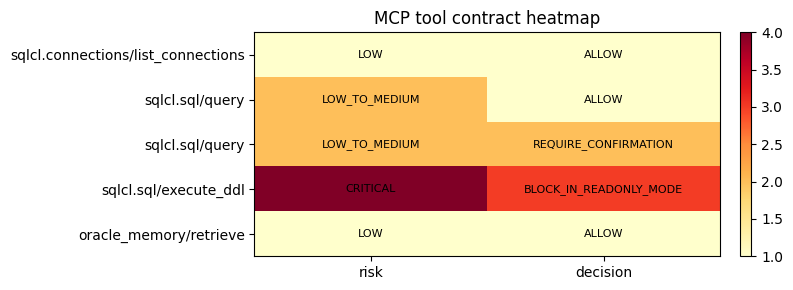

In [8]:
MCP_TOOL_POLICY = {
    "sqlcl.connections/list_connections": {
        "readOnlyHint": True,
        "destructiveHint": False,
        "requiresConfirmation": False,
        "risk": "LOW",
        "purpose": "Discover saved SQLcl connection aliases.",
    },
    "sqlcl.sql/query": {
        "readOnlyHint": True,
        "destructiveHint": False,
        "requiresConfirmation": False,
        "risk": "LOW_TO_MEDIUM",
        "purpose": "Run bounded SELECT statements through SQLcl MCP.",
    },
    "sqlcl.sql/execute_dml": {
        "readOnlyHint": False,
        "destructiveHint": False,
        "requiresConfirmation": True,
        "risk": "HIGH",
        "purpose": "Data-changing operations require confirmation and scoped privileges.",
    },
    "sqlcl.sql/execute_ddl": {
        "readOnlyHint": False,
        "destructiveHint": True,
        "requiresConfirmation": True,
        "risk": "CRITICAL",
        "purpose": "DDL operations require explicit approval and elevated privileges.",
    },
    "oracle_memory/retrieve": {
        "readOnlyHint": True,
        "destructiveHint": False,
        "requiresConfirmation": False,
        "risk": "LOW",
        "purpose": "Retrieve tenant-scoped Oracle AI Database memory.",
    },
}


def classify_mcp_tool_call(tool_name: str, sql_summary: str = "") -> dict:
    policy = MCP_TOOL_POLICY.get(tool_name, {
        "readOnlyHint": False,
        "destructiveHint": True,
        "requiresConfirmation": True,
        "risk": "UNKNOWN",
        "purpose": "Unknown tool; require review before use.",
    })
    lowered = f" {sql_summary.lower()} "
    write_terms = [" insert ", " update ", " delete ", " merge "]
    destructive_terms = [" drop ", " truncate ", " alter ", " grant ", " revoke "]
    write_detected = any(term in lowered for term in write_terms)
    destructive_detected = any(term in lowered for term in destructive_terms)

    decision = "ALLOW"
    reason = "Read-only or discovery operation."
    if policy["requiresConfirmation"] or write_detected:
        decision = "REQUIRE_CONFIRMATION"
        reason = "Write-capable operation detected."
    if policy["destructiveHint"] or destructive_detected:
        decision = "BLOCK_IN_READONLY_MODE"
        reason = "Destructive or DDL-like operation detected."

    return {
        "tool_name": tool_name,
        "risk": policy["risk"],
        "decision": decision,
        "read_only": policy["readOnlyHint"],
        "confirmation_required": policy["requiresConfirmation"] or write_detected or destructive_detected,
        "control_status": "SAFE" if decision == "ALLOW" else "CONTROLLED",
        "reason": reason,
    }


policy_examples = pd.DataFrame([
    classify_mcp_tool_call("sqlcl.connections/list_connections"),
    classify_mcp_tool_call("sqlcl.sql/query", "select owner, table_name from all_tables fetch first 10 rows only"),
    classify_mcp_tool_call("sqlcl.sql/query", "update support_jobs set reviewed = 'Y'"),
    classify_mcp_tool_call("sqlcl.sql/execute_ddl", "drop table old_memory"),
    classify_mcp_tool_call("oracle_memory/retrieve", "retrieve tenant scoped MCP setup memory"),
])

print("MCP tool contract gate:")
display_df(policy_examples)

plot_mcp_policy_heatmap(policy_examples)


**DEVELOPER PATTERN: MCP tool gate**

Use this when: You want to inspect or log what tool class a request falls into before execution.

Minimal call: `classify_mcp_tool_call("sqlcl.sql/query", "select ...")`

Expected output: dict with `risk`, `decision`, `confirmation_required`

Adapt for your app: Extend `MCP_TOOL_POLICY` with your own tool names and risk levels.

Production note: This gate is observability, not enforcement. Real enforcement stays in Oracle privileges.


## Step 5 - Create Oracle AI Database-Backed Memory Tables

The article separates memory into three practical categories:

- **Conversational memory**: user and assistant turns.
- **Operational memory**: MCP tool calls, inputs, outputs, status, and errors.
- **Semantic memory**: reusable knowledge chunks and embeddings.

The table names are prefixed with `CODEX_` so the demo is easy to identify and clean up.


In [9]:
RESET_DEMO = True

TABLES = [
    "CODEX_VALIDATION_CHECKS",
    "CODEX_KB_CHUNKS",
    "CODEX_TOOL_LOGS",
    "CODEX_CONVERSATIONAL_MEMORY",
]

DDL = {
    "codex_conversational_memory": """
        CREATE TABLE codex_conversational_memory (
            memory_id      NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
            tenant_id      VARCHAR2(64) NOT NULL,
            thread_id      VARCHAR2(128) NOT NULL,
            role           VARCHAR2(32) NOT NULL,
            content        CLOB NOT NULL,
            metadata_json  CLOB CHECK (metadata_json IS JSON),
            created_at     TIMESTAMP DEFAULT SYSTIMESTAMP NOT NULL
        )
    """,
    "codex_tool_logs": """
        CREATE TABLE codex_tool_logs (
            log_id         NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
            tenant_id      VARCHAR2(64) NOT NULL,
            thread_id      VARCHAR2(128) NOT NULL,
            tool_name      VARCHAR2(200) NOT NULL,
            tool_input     CLOB CHECK (tool_input IS JSON),
            tool_output    CLOB CHECK (tool_output IS JSON),
            status         VARCHAR2(32) NOT NULL,
            error_class    VARCHAR2(80),
            error_message  VARCHAR2(1000),
            created_at     TIMESTAMP DEFAULT SYSTIMESTAMP NOT NULL
        )
    """,
    "codex_kb_chunks": """
        CREATE TABLE codex_kb_chunks (
            chunk_id        NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
            tenant_id       VARCHAR2(64) NOT NULL,
            source_name     VARCHAR2(200) NOT NULL,
            category        VARCHAR2(80) NOT NULL,
            title           VARCHAR2(300) NOT NULL,
            chunk_text      CLOB NOT NULL,
            metadata_json   CLOB CHECK (metadata_json IS JSON),
            embedding_json  CLOB CHECK (embedding_json IS JSON),
            created_at      TIMESTAMP DEFAULT SYSTIMESTAMP NOT NULL
        )
    """,
    "codex_validation_checks": """
        CREATE TABLE codex_validation_checks (
            check_id       NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
            check_name     VARCHAR2(120) NOT NULL,
            status         VARCHAR2(32) NOT NULL,
            detail         VARCHAR2(1000),
            created_at     TIMESTAMP DEFAULT SYSTIMESTAMP NOT NULL
        )
    """,
}

if RESET_DEMO:
    safe_drop_index("CODEX_KB_TEXT_IDX")
    safe_drop_index("CODEX_KB_VECTOR_IDX")
    for table in TABLES:
        safe_drop_table(table)

for statement in DDL.values():
    execute_ddl(statement)

print("Oracle AI Database memory schema ready.")

Oracle AI Database memory schema ready.


## Step 6 - Insert a Sample Codex + MCP Workflow

These records are simulated teaching data. They show what an operational workflow should preserve, but they are not live SQLcl MCP telemetry captured from Codex CLI:

- what the user asked,
- what Codex planned,
- what MCP tool calls were attempted,
- which calls succeeded or failed,
- and what memory should be available later.

This is the key difference between assistant memory and system memory: the database gives us something queryable, auditable, and shareable across sessions.


In [10]:
SCENARIO = "support-job investigation"

conversation_rows = [
    ("TENANT_A", "thread-codex-mcp-001", "user",
     "Can you inspect failed jobs from the Oracle support schema and summarize what changed since yesterday?",
     {"client": "Codex CLI", "loop": "operational", "memory_type": "conversation"}),
    ("TENANT_A", "thread-codex-mcp-001", "assistant",
     "I will use SQLcl MCP tools to list connections, run a bounded read-only query, and summarize with evidence.",
     {"client": "Codex CLI", "loop": "operational", "planned_boundary": "SQLcl MCP"}),
    ("TENANT_A", "thread-codex-mcp-001", "assistant",
     "The investigation found two failed jobs: one permission issue and one stale index maintenance job.",
     {"client": "Codex CLI", "loop": "grounded_response", "sources": ["codex_tool_logs"]}),
    ("TENANT_B", "thread-codex-mcp-002", "user",
     "Show the onboarding validation checklist for MCP connections.",
     {"client": "Codex CLI", "loop": "operational", "memory_type": "conversation"}),
]

tool_log_rows = [
    ("TENANT_A", "thread-codex-mcp-001", "sqlcl.connections/list_connections",
     {"requested_by": "Codex CLI"},
     {"connections": [CONFIG["SQLCL_CONNECTION_NAME"]], "selected": CONFIG["SQLCL_CONNECTION_NAME"]},
     "SUCCESS", None, None),
    ("TENANT_A", "thread-codex-mcp-001", "sqlcl.sql/query",
     {"connection": CONFIG["SQLCL_CONNECTION_NAME"], "sql_summary": "select failed jobs with bounded result set"},
     {"rows": 2, "columns": ["job_name", "status", "error_code", "last_run"]},
     "SUCCESS", None, None),
    ("TENANT_A", "thread-codex-mcp-001", "sqlcl.sql/query",
     {"connection": CONFIG["SQLCL_CONNECTION_NAME"], "sql_summary": "attempted write to mark job reviewed"},
     {"rows": 0},
     "DENIED", "PRIVILEGE_SCOPE", "Read-only role blocked a write operation. This is expected in validation mode."),
    ("TENANT_A", "thread-codex-mcp-001", "oracle_memory/retrieve",
     {"query": "MCP saved connection setup", "top_k": 3},
     {"rows": 3, "quality": "usable"},
     "SUCCESS", None, None),
    ("TENANT_B", "thread-codex-mcp-002", "oracle_memory/retrieve",
     {"query": "onboarding validation checklist for MCP connections", "top_k": 3},
     {"rows": 1, "quality": "weak"},
     "WARNING", "RETRIEVAL_QUALITY", "Only one tenant-scoped memory chunk matched the query."),
]

try:
    cursor.executemany(
        """INSERT INTO codex_conversational_memory
            (tenant_id, thread_id, role, content, metadata_json)
        VALUES (:1, :2, :3, :4, :5)""",
        [(tenant, thread, role, content, json.dumps(metadata))
         for tenant, thread, role, content, metadata in conversation_rows],
    )
    cursor.executemany(
        """INSERT INTO codex_tool_logs
            (tenant_id, thread_id, tool_name, tool_input, tool_output, status, error_class, error_message)
        VALUES (:1, :2, :3, :4, :5, :6, :7, :8)""",
        [(tenant, thread, tool, json.dumps(tool_input), json.dumps(tool_output), status, error_class, error_message)
         for tenant, thread, tool, tool_input, tool_output, status, error_class, error_message in tool_log_rows],
    )
    connection.commit()
except Exception as exc:
    connection.rollback()
    raise RuntimeError(f"Step 6 insert failed and was rolled back: {exc}") from exc

memory_load_summary = pd.DataFrame([
    {"memory_stream": "conversational_memory", "rows_loaded": len(conversation_rows), "purpose": "Codex/user turns and grounded responses"},
    {"memory_stream": "operational_tool_logs", "rows_loaded": len(tool_log_rows), "purpose": "MCP tool call audit trail"},
])
display_df(memory_load_summary)


,memory_stream,rows_loaded,purpose
0,conversational_memory,4,Codex/user turns and grounded responses
1,operational_tool_logs,5,MCP tool call audit trail


## Step 7 - Query Operational Memory

These queries are where the workflow becomes auditable. Instead of asking "why did the assistant answer that way?", we can inspect the execution trail:

- which MCP tools ran,
- which tenant/thread they belonged to,
- which operations failed,
- and whether failures were expected privilege boundaries or real runtime issues.


In [11]:
tool_status = run_sql("""
SELECT
    tenant_id,
    tool_name,
    status,
    COUNT(*) AS calls
FROM codex_tool_logs
GROUP BY tenant_id, tool_name, status
ORDER BY tenant_id, tool_name, status
""")

status_order = {"SUCCESS": 1, "WARNING": 2, "DENIED": 3, "ERROR": 4}
tool_status["status_rank"] = tool_status["status"].map(status_order).fillna(99)
tool_status = tool_status.sort_values(["tenant_id", "status_rank", "tool_name"]).drop(columns=["status_rank"])
tool_status["control_status"] = tool_status["status"].map({
    "SUCCESS": "OK",
    "DENIED": "CONTROLLED",
    "WARNING": "REVIEW",
    "ERROR": "ACTION_NEEDED",
}).fillna("REVIEW")

print("MCP operational call matrix:")
display_df(tool_status)


MCP operational call matrix:


,tenant_id,tool_name,status,calls,control_status
0,TENANT_A,oracle_memory/retrieve,SUCCESS,1,OK
1,TENANT_A,sqlcl.connections/list_connections,SUCCESS,1,OK
3,TENANT_A,sqlcl.sql/query,SUCCESS,1,OK
2,TENANT_A,sqlcl.sql/query,DENIED,1,CONTROLLED
4,TENANT_B,oracle_memory/retrieve,WARNING,1,REVIEW


In [12]:
thread_timeline = run_sql("""
SELECT
    'CONVERSATION' AS event_kind,
    tenant_id,
    thread_id,
    role AS actor,
    DBMS_LOB.SUBSTR(content, 220, 1) AS summary,
    created_at
FROM codex_conversational_memory
WHERE thread_id = :thread_id
UNION ALL
SELECT
    'MCP_TOOL' AS event_kind,
    tenant_id,
    thread_id,
    tool_name AS actor,
    status || CASE WHEN error_class IS NOT NULL THEN ' / ' || error_class ELSE '' END AS summary,
    created_at
FROM codex_tool_logs
WHERE thread_id = :thread_id
ORDER BY created_at, event_kind
""", {"thread_id": "thread-codex-mcp-001"})

thread_timeline.insert(0, "step", range(1, len(thread_timeline) + 1))
thread_timeline["created_at"] = pd.to_datetime(thread_timeline["created_at"]).dt.strftime("%H:%M:%S")

print("Single-thread Codex MCP execution timeline:")
display_df(thread_timeline)

Single-thread Codex MCP execution timeline:


,step,event_kind,tenant_id,thread_id,actor,summary,created_at
0,1,CONVERSATION,TENANT_A,thread-codex-mcp-001,assistant,The investigation found two failed jobs: one p...,10:32:43
1,2,CONVERSATION,TENANT_A,thread-codex-mcp-001,assistant,I will use SQLcl MCP tools to list connections...,10:32:43
2,3,CONVERSATION,TENANT_A,thread-codex-mcp-001,user,Can you inspect failed jobs from the Oracle su...,10:32:43
3,4,MCP_TOOL,TENANT_A,thread-codex-mcp-001,sqlcl.sql/query,DENIED / PRIVILEGE_SCOPE,10:32:43
4,5,MCP_TOOL,TENANT_A,thread-codex-mcp-001,sqlcl.sql/query,SUCCESS,10:32:43
5,6,MCP_TOOL,TENANT_A,thread-codex-mcp-001,oracle_memory/retrieve,SUCCESS,10:32:43
6,7,MCP_TOOL,TENANT_A,thread-codex-mcp-001,sqlcl.connections/list_connections,SUCCESS,10:32:43


In [13]:
audit_view = run_sql("""
SELECT
    tenant_id,
    thread_id,
    tool_name,
    status,
    error_class,
    error_message,
    created_at
FROM codex_tool_logs
WHERE status <> 'SUCCESS'
ORDER BY created_at DESC
""")

if not audit_view.empty:
    audit_view["control_status"] = audit_view["error_class"].map({
        "PRIVILEGE_SCOPE": "CONTROLLED",
        "RETRIEVAL_QUALITY": "REVIEW",
    }).fillna("ACTION_NEEDED")
    audit_view["control_interpretation"] = audit_view["error_class"].map({
        "PRIVILEGE_SCOPE": "Expected boundary: read-only mode blocked a write attempt.",
        "RETRIEVAL_QUALITY": "Retrieval quality signal captured for review.",
    }).fillna("Review required.")
    audit_view["created_at"] = pd.to_datetime(audit_view["created_at"]).dt.strftime("%H:%M:%S")

print("Controlled review signals:")
display_df(audit_view, "No non-success tool calls found.")


Controlled review signals:


,tenant_id,thread_id,tool_name,status,error_class,error_message,created_at,control_status,control_interpretation
0,TENANT_B,thread-codex-mcp-002,oracle_memory/retrieve,WARNING,RETRIEVAL_QUALITY,Only one tenant-scoped memory chunk matched th...,10:32:43,REVIEW,Retrieval quality signal captured for review.
1,TENANT_A,thread-codex-mcp-001,sqlcl.sql/query,DENIED,PRIVILEGE_SCOPE,Read-only role blocked a write operation. This...,10:32:43,CONTROLLED,Expected boundary: read-only mode blocked a wr...


## Step 8 - Insert Knowledge Memory

These chunks represent the durable memory that should outlive a single Codex CLI session. They are written as tenant-scoped chunks so retrieval can enforce boundaries. In a production workflow, this is the layer Oracle AI Agent Memory manages through its package API. You are building it manually here so the structure is fully visible.

The notebook uses deterministic demo embeddings later, so no external embedding service or API key is required.


In [14]:
knowledge_rows = [
    ("mcp_setup", "SQLcl MCP execution boundary",
     "Codex CLI should connect to Oracle AI Database through SQLcl MCP using sql -mcp. The assistant calls explicit tools instead of receiving unrestricted database access.",
     "Setup Guide", "high"),
    ("mcp_setup", "Saved SQLcl connections for MCP",
     "SQLcl MCP relies on saved SQLcl connection profiles stored under the user connection store. MCP-compatible connections should persist the password with savepwd so Codex CLI can launch the server reproducibly.",
     "Setup Guide", "high"),
    ("security", "Least privilege first",
     "Operational rollout should start with read-only database roles, schema allowlists, and explicit confirmation workflows for high-impact write operations.",
     "Engineering guidance", "high"),
    ("observability", "Tool logging baseline",
     "Log the tool name, thread ID, tenant ID, timestamp, status, and sanitized input and output summaries for every MCP tool call.",
     "Engineering guidance", "high"),
    ("langchain", "LangChain as orchestration glue",
     "LangChain is useful for declaring retrievers and composing retrieval-first pipelines, but security enforcement should stay in database privileges and runtime boundaries.",
     "Where LangChain adds value", "medium"),
    ("retrieval", "Retrieval quality failure mode",
     "Fluent but weakly grounded answers usually point to poor chunking, sparse metadata, weak retrieval settings, or a corpus that no longer matches real query patterns.",
     "Failure modes", "medium"),
    ("memory_model", "Codex memory versus Oracle memory",
     "Codex memory improves assistant continuity, while Oracle memory provides durable, queryable, governed system memory across users, sessions, and tools.",
     "Codex memory vs Oracle memory", "high"),
]

tenant_b_row = (
    "TENANT_B", "tenant_b_validation", "mcp_setup", "Tenant B onboarding note",
    "Tenant B allows read-only SQLcl MCP onboarding only after the connection alias is reviewed by the platform team.",
    {"article_section": "Tenant validation", "priority": "medium"},
)

insert_rows = [
    ("TENANT_A", "codex_mcp_oracle_ai_database_article", category, title, text,
     {"article_section": section, "priority": priority})
    for category, title, text, section, priority in knowledge_rows
] + [tenant_b_row]

try:
    cursor.executemany(
        """
        INSERT INTO codex_kb_chunks
            (tenant_id, source_name, category, title, chunk_text, metadata_json)
        VALUES (:1, :2, :3, :4, :5, :6)
        """,
        [(tenant, source, category, title, text, json.dumps(metadata))
        for tenant, source, category, title, text, metadata in insert_rows],
    )

    connection.commit()
except Exception as exc:
    connection.rollback()
    raise RuntimeError(f"Step 7 insert failed and was rolled back: {exc}") from exc

print(f"Inserted {len(insert_rows)} knowledge chunks.")

Inserted 8 knowledge chunks.


### Where We Are

The operational and audit layer is now in place:

- SQLcl MCP boundary has been validated (or flagged for local setup).
- Oracle AI Database memory tables exist and are populated with simulated Codex/MCP traces.
- Tool call outcomes, including controlled failures, are stored and queryable.

The notebook now shifts to the retrieval and grounding layer: lexical search, vector search, hybrid retrieval, and assembling evidence packages for the assistant.


## Step 9 - Lexical Retrieval

Lexical retrieval is important for exact phrases like `sql -mcp`, `savepwd`, connection aliases, error codes, and policy terms.

This section tries Oracle Text first. If Oracle Text privileges are not available in your local database, the notebook falls back to a simple tenant-scoped `LIKE` search so the rest of the workflow remains runnable.


In [15]:
ORACLE_TEXT_READY = False
oracle_text_error = None

try:
    safe_drop_index("CODEX_KB_TEXT_IDX")
    execute_ddl("""
    CREATE INDEX codex_kb_text_idx
    ON codex_kb_chunks(chunk_text)
    INDEXTYPE IS CTXSYS.CONTEXT
    """)
    cursor.execute("BEGIN CTX_DDL.SYNC_INDEX('CODEX_KB_TEXT_IDX'); END;")
    connection.commit()
    ORACLE_TEXT_READY = True
    print("Oracle Text index is ready.")
except Exception as exc:
    connection.rollback()
    oracle_text_error = str(exc)
    print("Oracle Text is not available in this environment. Falling back to LIKE search.")


def text_query_terms(query: str) -> list[str]:
    stopwords = {"and", "or", "the", "with", "what", "when", "where", "should", "does", "from", "this", "that"}
    terms = []
    for term in re.findall(r"[A-Za-z0-9_\-]+", query.lower()):
        if len(term) > 2 and term not in stopwords:
            terms.append(term)
    return terms[:8]


def like_search(query: str, tenant_id: str = "TENANT_A", top_k: int = 5) -> pd.DataFrame:
    terms = text_query_terms(query)
    if not terms:
        return pd.DataFrame(columns=["chunk_id", "tenant_id", "category", "title", "chunk_text", "lexical_score"])

    params = {"tenant_id": tenant_id}
    predicates = []
    score_parts = []
    for idx, term in enumerate(terms):
        pred_key = f"pred_term_{idx}"
        score_key = f"score_term_{idx}"
        params[pred_key] = f"%{term}%"
        params[score_key] = f"%{term}%"
        predicates.append(f"LOWER(chunk_text) LIKE :{pred_key}")
        score_parts.append(f"CASE WHEN LOWER(chunk_text) LIKE :{score_key} THEN 1 ELSE 0 END")

    sql = f"""
    SELECT
        chunk_id,
        tenant_id,
        category,
        title,
        DBMS_LOB.SUBSTR(chunk_text, 500, 1) AS chunk_text,
        ({' + '.join(score_parts)}) AS lexical_score
    FROM codex_kb_chunks
    WHERE tenant_id = :tenant_id
      AND ({' OR '.join(predicates)})
    ORDER BY lexical_score DESC, chunk_id
    FETCH FIRST {int(top_k)} ROWS ONLY
    """
    return run_sql(sql, params)


def oracle_text_query(query: str) -> str:
    terms = text_query_terms(query)
    return " OR ".join(terms) if terms else query


def lexical_search(query: str, tenant_id: str = "TENANT_A", top_k: int = 5) -> pd.DataFrame:
    top_k = int(top_k)
    if ORACLE_TEXT_READY:
        try:
            return run_sql(f"""
            SELECT
                chunk_id,
                tenant_id,
                category,
                title,
                DBMS_LOB.SUBSTR(chunk_text, 500, 1) AS chunk_text,
                SCORE(1) AS lexical_score
            FROM codex_kb_chunks
            WHERE tenant_id = :tenant_id
              AND CONTAINS(chunk_text, :query, 1) > 0
            ORDER BY lexical_score DESC
            FETCH FIRST {top_k} ROWS ONLY
            """, {"tenant_id": tenant_id, "query": oracle_text_query(query)})
        except Exception as exc:
            print("Oracle Text query could not be parsed for this input. Falling back to LIKE search.")
            connection.rollback()
            return like_search(query, tenant_id=tenant_id, top_k=top_k)

    return like_search(query, tenant_id=tenant_id, top_k=top_k)


lexical_results = lexical_search("Codex MCP saved connection savepwd", tenant_id="TENANT_A", top_k=5)
display_df(lexical_results)

Oracle Text is not available in this environment. Falling back to LIKE search.


,chunk_id,tenant_id,category,title,chunk_text,lexical_score
0,2,TENANT_A,mcp_setup,Saved SQLcl connections for MCP,SQLcl MCP relies on saved SQLcl connection pro...,5
1,1,TENANT_A,mcp_setup,SQLcl MCP execution boundary,Codex CLI should connect to Oracle AI Database...,2
2,4,TENANT_A,observability,Tool logging baseline,"Log the tool name, thread ID, tenant ID, times...",1
3,7,TENANT_A,memory_model,Codex memory versus Oracle memory,"Codex memory improves assistant continuity, wh...",1


**What this fallback means:**

Oracle Text requires CTXSYS privileges which may not be available in all local environments. The LIKE fallback keeps the notebook runnable and produces correct results for small corpora, but loses relevance ranking for larger datasets.

For this notebook, `FALLBACK` is an acceptable portable demo path. Enable Oracle Text only when you want production lexical ranking.

**How to enable the production path:**

Grant `CTXSYS.CONTEXT` indextype privileges to your Oracle user and rerun this cell. No other code changes are needed.


**DEVELOPER PATTERN: Lexical retrieval**

Use this when: Queries contain exact setup terms like `sql -mcp`, `savepwd`, error codes, object names.

Minimal call: `lexical_search("savepwd connection alias", tenant_id="TENANT_A", top_k=5)`

Expected output: DataFrame with `lexical_score` ranked by term match count.

Adapt for your app: Replace LIKE fallback with Oracle Text once CTXSYS privileges are available.

Production note: Schedule `CTX_DDL.SYNC_INDEX` to keep the text index fresh after bulk inserts.


## Step 10 - Vector Search with Deterministic Demo Embeddings

Vector search is part of the article's Oracle AI Database memory story. In a real application, embeddings would usually come from a model and be indexed with Oracle AI Database vector capabilities.

For a portable notebook, this section uses deterministic domain embeddings. The dimensions are intentionally meaningful: MCP boundary, SQLcl runtime, Oracle AI Database, security, observability, memory, retrieval, and LangChain. That makes the output easier to inspect than a random vector demo.


In [16]:
import hashlib
import numpy as np

TERM_GROUPS = {
    "codex_interface": ["codex", "cli", "assistant", "conversation", "interaction", "client"],
    "mcp_boundary": ["mcp", "tool", "tools", "contract", "boundary", "explicit", "server"],
    "sqlcl_runtime": ["sqlcl", "sql", "savepwd", "connection", "connections", "alias", "profile"],
    "oracle_ai_database": ["oracle", "database", "ai", "table", "tables", "json", "vector", "text"],
    "security": ["privilege", "privileges", "role", "roles", "allowlist", "confirmation", "read-only", "readonly"],
    "observability": ["log", "logs", "logging", "audit", "timestamp", "status", "trace", "tool"],
    "memory": ["memory", "history", "durable", "system", "session", "tenant"],
    "retrieval": ["retrieval", "retrieve", "semantic", "lexical", "hybrid", "evidence", "grounded"],
    "langchain": ["langchain", "orchestration", "retriever", "pipeline", "runnable"],
    "reliability": ["failure", "fallback", "validation checklist", "diagnostic", "quality", "weak"],
}

EMBEDDING_DIM = len(TERM_GROUPS)
EMBEDDING_LABELS = list(TERM_GROUPS.keys())


def tokenize(text: str) -> list[str]:
    return [token.lower() for token in re.findall(r"[A-Za-z0-9_\-]+", text)]


def demo_embed(text: str, dim: int = EMBEDDING_DIM) -> np.ndarray:
    tokens = tokenize(text)
    vector = np.zeros(dim, dtype=float)
    for idx, label in enumerate(EMBEDDING_LABELS):
        terms = TERM_GROUPS[label]
        vector[idx] = sum(1.0 for token in tokens for term in terms if token == term or token.startswith(term))

    # Add a small deterministic signal so ties remain stable without hiding the semantic dimensions.
    for token in tokens:
        digest = hashlib.sha256(token.encode("utf-8")).hexdigest()
        vector[int(digest[:8], 16) % dim] += 0.05

    norm = np.linalg.norm(vector)
    if norm == 0:
        return vector
    return vector / norm


def vector_to_json(vector: np.ndarray) -> str:
    return json.dumps([round(float(value), 6) for value in vector.tolist()])


def parse_embedding(value) -> np.ndarray:
    value = lob_to_text(value)
    if isinstance(value, np.ndarray):
        return value.astype(float)
    if isinstance(value, list):
        return np.array(value, dtype=float)
    if isinstance(value, str):
        return np.array(json.loads(value), dtype=float)
    raise TypeError(f"Unsupported embedding value type: {type(value)!r}")


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    if denominator == 0:
        return 0.0
    return float(np.dot(a, b) / denominator)


chunk_rows = run_sql("SELECT chunk_id, chunk_text FROM codex_kb_chunks ORDER BY chunk_id")
for _, row in chunk_rows.iterrows():
    vector = demo_embed(row["chunk_text"])
    cursor.execute(
        "UPDATE codex_kb_chunks SET embedding_json = :embedding_json WHERE chunk_id = :chunk_id",
        {"embedding_json": vector_to_json(vector), "chunk_id": int(row["chunk_id"])},
    )
connection.commit()

embedding_profile = pd.DataFrame({
    "dimension": EMBEDDING_LABELS,
    "purpose": [
        "Codex CLI interface",
        "MCP tool boundary and explicit contracts",
        "SQLcl runtime, saved connections, savepwd",
        "Oracle AI Database multimodal storage",
        "Privileges, confirmation, read-only controls",
        "Tool logs, audit, traceability",
        "Durable system memory",
        "Lexical, semantic, and hybrid retrieval",
        "LangChain orchestration",
        "Validation checks, fallback, diagnostics",
    ],
})

print(f"Stored deterministic semantic demo embeddings for {len(chunk_rows)} chunks.")
display(embedding_profile)


Stored deterministic semantic demo embeddings for 8 chunks.


,dimension,purpose
0,codex_interface,Codex CLI interface
1,mcp_boundary,MCP tool boundary and explicit contracts
2,sqlcl_runtime,"SQLcl runtime, saved connections, savepwd"
3,oracle_ai_database,Oracle AI Database multimodal storage
4,security,"Privileges, confirmation, read-only controls"
5,observability,"Tool logs, audit, traceability"
6,memory,Durable system memory
7,retrieval,"Lexical, semantic, and hybrid retrieval"
8,langchain,LangChain orchestration
9,reliability,"Validation checks, fallback, diagnostics"


In [17]:
NATIVE_VECTOR_READY = False
native_vector_error = None

try:
    execute_ddl(f"ALTER TABLE codex_kb_chunks ADD (embedding_vector VECTOR({EMBEDDING_DIM}, FLOAT32))")
    rows_for_vector = run_sql("SELECT chunk_id, embedding_json FROM codex_kb_chunks ORDER BY chunk_id")
    for _, row in rows_for_vector.iterrows():
        vector_json = vector_to_json(parse_embedding(row["embedding_json"])) if "parse_embedding" in globals() else json.dumps(row["embedding_json"])
        cursor.execute(
            "UPDATE codex_kb_chunks SET embedding_vector = TO_VECTOR(:embedding_json) WHERE chunk_id = :chunk_id",
            {"embedding_json": vector_json, "chunk_id": int(row["chunk_id"])},
        )
    connection.commit()
    NATIVE_VECTOR_READY = True
    print("Oracle AI Database native VECTOR path is ready.")
except Exception as exc:
    connection.rollback()
    native_vector_error = str(exc)
    print("Native VECTOR path is not available in this environment; using portable Python cosine fallback.")

vector_mode = pd.DataFrame([{
    "vector_path": "Oracle AI Database native VECTOR" if NATIVE_VECTOR_READY else "Portable cosine fallback",
    "embedding_dimensions": EMBEDDING_DIM,
    "stored_representation": "VECTOR column + JSON backup" if NATIVE_VECTOR_READY else "JSON embedding column",
    "purpose": "Rank memory chunks by semantic similarity",
}])
display_df(vector_mode)

Oracle AI Database native VECTOR path is ready.


,vector_path,embedding_dimensions,stored_representation,purpose
0,Oracle AI Database native VECTOR,10,VECTOR column + JSON backup,Rank memory chunks by semantic similarity


**What this fallback means:** 

Native VECTOR requires Oracle AI Database with vector support enabled. The Python cosine fallback produces identical rankings for this demo corpus. For datasets over a few thousand chunks, native VECTOR indexes are significantly faster.

**How to enable the production path:** 

Use Oracle AI Database 23ai and confirm VECTOR column support. The `embedding_vector` column and `TO_VECTOR()` calls in the code are already wired, only the environment needs to change.


Vector search candidates:


,chunk_id,tenant_id,category,title,chunk_text,vector_distance,vector_score
0,2,TENANT_A,mcp_setup,Saved SQLcl connections for MCP,SQLcl MCP relies on saved SQLcl connection pro...,0.028355,0.971645
1,1,TENANT_A,mcp_setup,SQLcl MCP execution boundary,Codex CLI should connect to Oracle AI Database...,0.368021,0.631979
2,3,TENANT_A,security,Least privilege first,Operational rollout should start with read-onl...,0.708520,0.291480
3,7,TENANT_A,memory_model,Codex memory versus Oracle memory,"Codex memory improves assistant continuity, wh...",0.798728,0.201272
4,4,TENANT_A,observability,Tool logging baseline,"Log the tool name, thread ID, tenant ID, times...",0.835876,0.164124


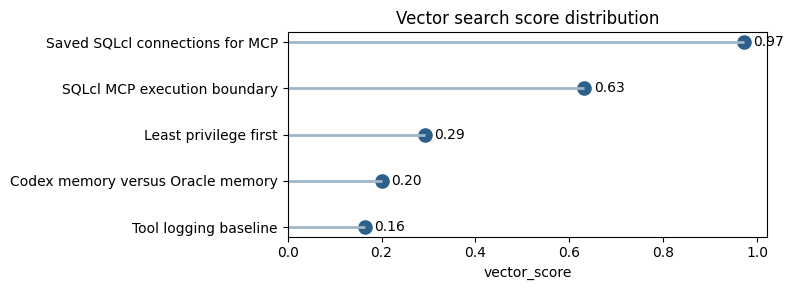

In [18]:
def vector_search(query: str, tenant_id: str = "TENANT_A", top_k: int = 5) -> pd.DataFrame:
    top_k = int(top_k)
    query_vector = demo_embed(query)
    query_vector_json = vector_to_json(query_vector)

    if NATIVE_VECTOR_READY:
        try:
            return run_sql(f"""
            SELECT
                chunk_id,
                tenant_id,
                category,
                title,
                DBMS_LOB.SUBSTR(chunk_text, 500, 1) AS chunk_text,
                VECTOR_DISTANCE(embedding_vector, TO_VECTOR(:query_vector), COSINE) AS vector_distance,
                1 - VECTOR_DISTANCE(embedding_vector, TO_VECTOR(:query_vector), COSINE) AS vector_score
            FROM codex_kb_chunks
            WHERE tenant_id = :tenant_id
            ORDER BY vector_distance
            FETCH FIRST {top_k} ROWS ONLY
            """, {"tenant_id": tenant_id, "query_vector": query_vector_json})
        except Exception as exc:
            print("Native vector search failed. Falling back to Python cosine search.")
            connection.rollback()

    rows = run_sql("""
    SELECT
        chunk_id,
        tenant_id,
        category,
        title,
        DBMS_LOB.SUBSTR(chunk_text, 500, 1) AS chunk_text,
        embedding_json
    FROM codex_kb_chunks
    WHERE tenant_id = :tenant_id
    """, {"tenant_id": tenant_id})

    scored = []
    for _, row in rows.iterrows():
        stored_vector = parse_embedding(row["embedding_json"])
        score = cosine_similarity(query_vector, stored_vector)
        scored.append({
            "chunk_id": row["chunk_id"],
            "tenant_id": row["tenant_id"],
            "category": row["category"],
            "title": row["title"],
            "chunk_text": row["chunk_text"],
            "vector_distance": 1 - score,
            "vector_score": score,
        })

    return pd.DataFrame(scored).sort_values("vector_score", ascending=False).head(top_k).reset_index(drop=True)


semantic_results = vector_search("How should Codex use SQLcl MCP safely with saved connections and least privilege?", tenant_id="TENANT_A", top_k=5)
print("Vector search candidates:")
display_df(semantic_results)
plot_vector_lollipop(semantic_results)

**DEVELOPER PATTERN: Vector search**

Use this when: Users paraphrase intent or ask conceptual questions without using exact setup terms.

Minimal call: `vector_search("how should Codex connect safely", tenant_id="TENANT_A", top_k=5)`

Expected output: DataFrame with `vector_score` 0.0–1.0, ranked by cosine similarity.

Adapt for your app: Replace `demo_embed()` with your embedding model; keep the same function signature.

Production note: Native VECTOR indexes outperform Python cosine at scale. The fallback is for portability only.


## Step 11 - Hybrid Retrieval

Hybrid retrieval combines:

- lexical precision for exact setup terms,
- semantic similarity for paraphrases,
- tenant filtering for governance.

This is the pattern the article is advocating: MCP controls execution, while Oracle memory provides durable and governed retrieval.


Hybrid retrieval ranking:


,chunk_id,tenant_id,category,title,chunk_text,hybrid_score
0,2,TENANT_A,mcp_setup,Saved SQLcl connections for MCP,SQLcl MCP relies on saved SQLcl connection pro...,1.0000
1,1,TENANT_A,mcp_setup,SQLcl MCP execution boundary,Codex CLI should connect to Oracle AI Database...,0.6851
2,4,TENANT_A,observability,Tool logging baseline,"Log the tool name, thread ID, tenant ID, times...",0.4492
3,7,TENANT_A,memory_model,Codex memory versus Oracle memory,"Codex memory improves assistant continuity, wh...",0.2377
4,3,TENANT_A,security,Least privilege first,Operational rollout should start with read-onl...,0.2174


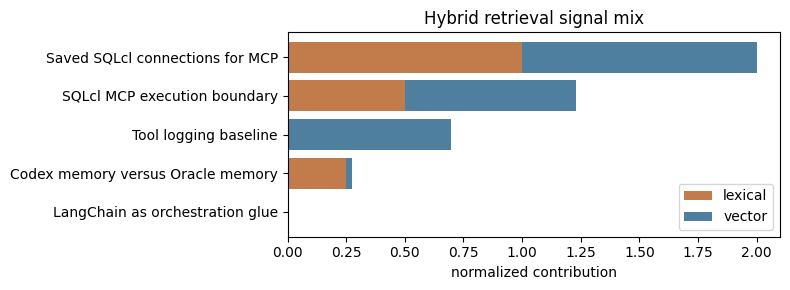

In [19]:
def normalize_series(values: pd.Series) -> pd.Series:
    if values.empty:
        return values
    max_value = values.max()
    min_value = values.min()
    if max_value == min_value:
        return pd.Series([1.0] * len(values), index=values.index)
    return (values - min_value) / (max_value - min_value)


def hybrid_search(query: str, tenant_id: str = "TENANT_A", top_k: int = 5) -> pd.DataFrame:
    lexical = lexical_search(query, tenant_id=tenant_id, top_k=10)
    semantic = vector_search(query, tenant_id=tenant_id, top_k=10)

    combined: dict[int, dict] = {}

    if lexical is not None and not lexical.empty:
        lexical = lexical.copy()
        lexical["lexical_score_norm"] = normalize_series(lexical["lexical_score"].astype(float))
        for _, row in lexical.iterrows():
            chunk_id = int(row["chunk_id"])
            combined.setdefault(chunk_id, row.to_dict())
            combined[chunk_id]["lexical_score_norm"] = float(row["lexical_score_norm"])

    if semantic is not None and not semantic.empty:
        semantic = semantic.copy()
        semantic["vector_score_norm"] = normalize_series(semantic["vector_score"].astype(float))
        for _, row in semantic.iterrows():
            chunk_id = int(row["chunk_id"])
            combined.setdefault(chunk_id, row.to_dict())
            combined[chunk_id]["vector_score_norm"] = float(row["vector_score_norm"])
            combined[chunk_id]["vector_score"] = float(row["vector_score"])

    records = []
    for record in combined.values():
        lexical_part = float(record.get("lexical_score_norm", 0.0) or 0.0)
        vector_part = float(record.get("vector_score_norm", 0.0) or 0.0)
        operational_boost = 0.10 if record.get("category") in ["mcp_setup", "security", "observability"] else 0.0
        record["hybrid_score"] = round((0.45 * lexical_part) + (0.45 * vector_part) + operational_boost, 4)
        records.append(record)

    if not records:
        return pd.DataFrame(columns=["chunk_id", "tenant_id", "category", "title", "chunk_text", "hybrid_score"])

    columns = ["chunk_id", "tenant_id", "category", "title", "chunk_text", "hybrid_score"]
    return pd.DataFrame(records).sort_values("hybrid_score", ascending=False)[columns].head(top_k).reset_index(drop=True)


hybrid_results = hybrid_search("Codex MCP should use saved SQLcl connections, tool boundaries, logging, and least privilege", top_k=5)
print("Hybrid retrieval ranking:")
display_df(hybrid_results)
plot_hybrid_signal_mix("Codex MCP should use saved SQLcl connections, tool boundaries, logging, and least privilege", top_k=5)

**DEVELOPER PATTERN: Hybrid retrieval**

Use this when: Production queries mix exact terms and paraphrased intent.

Minimal call: `hybrid_search("MCP saved connections least privilege", tenant_id="TENANT_A", top_k=5)`

Expected output: DataFrame with `hybrid_score` combining lexical + vector + operational boost.

Adapt for your app: Tune the 0.45/0.45/0.10 weights to match your corpus and query patterns.

Production note: The operational boost rewards mcp_setup, security, and observability categories. Adjust categories to match your domain.


## Step 12 - Retrieval-First Grounding Policy

This notebook does not call an LLM. Instead, it builds the context package that an operational assistant should use before generating a final answer.

Policy:

1. Retrieve tenant-scoped memory first.
2. If evidence is weak or missing, say context is insufficient.
3. Keep the response grounded in retrieved memory and tool outcomes.
4. Log tool calls and retrieval attempts.


In [20]:
def build_grounding_package(question: str, tenant_id: str = "TENANT_A", min_score: float = 0.20) -> dict:
    evidence = hybrid_search(question, tenant_id=tenant_id, top_k=4)
    if evidence.empty or float(evidence.iloc[0]["hybrid_score"]) < min_score:
        return {
            "status": "INSUFFICIENT_CONTEXT",
            "question": question,
            "tenant_id": tenant_id,
            "evidence": [],
            "instruction": "Ask a clarifying question or run a safer retrieval path before answering.",
        }

    evidence_items = evidence.to_dict(orient="records")
    for item in evidence_items:
        if isinstance(item.get("chunk_text"), str) and len(item["chunk_text"]) > 800:
            item["chunk_text"] = item["chunk_text"][:800] + "... [truncated]"
    return {
        "status": "READY",
        "question": question,
        "tenant_id": tenant_id,
        "evidence": evidence_items,
        "instruction": "Answer using only the retrieved evidence and relevant tool outcomes.",
    }


grounding_package = build_grounding_package(
    "What should we log first when Codex uses SQLcl MCP?",
    tenant_id="TENANT_A",
)

evidence_table = pd.DataFrame(grounding_package["evidence"])
print("Retrieval-first grounding package:")
print(f"Status: {grounding_package['status']}")
print(f"Instruction: {grounding_package['instruction']}")
display_df(evidence_table[["title", "category", "hybrid_score", "chunk_text"]])

Retrieval-first grounding package:
Status: READY
Instruction: Answer using only the retrieved evidence and relevant tool outcomes.


,title,category,hybrid_score,chunk_text
0,Saved SQLcl connections for MCP,mcp_setup,1.0000,SQLcl MCP relies on saved SQLcl connection pro...
1,SQLcl MCP execution boundary,mcp_setup,0.9274,Codex CLI should connect to Oracle AI Database...
2,Tool logging baseline,observability,0.5788,"Log the tool name, thread ID, tenant ID, times..."
3,Codex memory versus Oracle memory,memory_model,0.1517,"Codex memory improves assistant continuity, wh..."


## Step 13 - Interactive Retrieval Playground

Use this section to test different Codex-style questions against the Oracle AI Database memory layer. It helps show how the same memory substrate supports MCP setup, security boundaries, logging, and LangChain orchestration.

Change `selected_question` to one of the examples or write your own.


Selected question: tool_boundary
Why is MCP safer than giving the assistant implicit database access?


,title,category,hybrid_score,chunk_text
0,SQLcl MCP execution boundary,mcp_setup,1.0000,Codex CLI should connect to Oracle AI Database...
1,Saved SQLcl connections for MCP,mcp_setup,0.2365,SQLcl MCP relies on saved SQLcl connection pro...
2,Tool logging baseline,observability,0.2007,"Log the tool name, thread ID, tenant ID, times..."
3,Codex memory versus Oracle memory,memory_model,0.1883,"Codex memory improves assistant continuity, wh..."


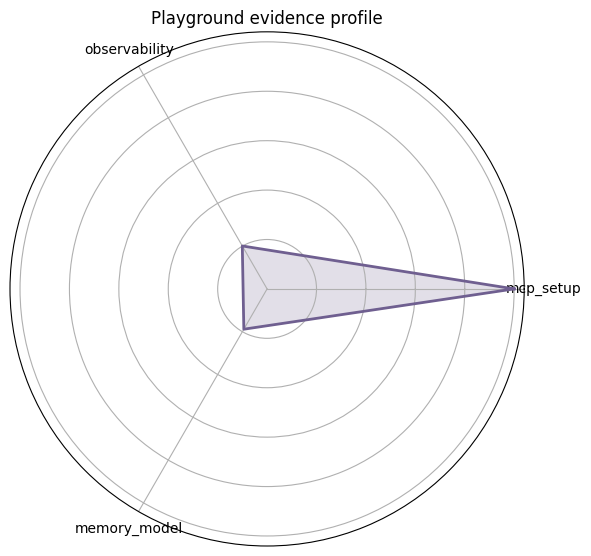

In [21]:
question_bank = {
    "mcp_setup": "How should Codex CLI connect to Oracle AI Database through SQLcl MCP?",
    "tool_boundary": "Why is MCP safer than giving the assistant implicit database access?",
    "memory_split": "What should stay in Codex memory and what should stay in Oracle memory?",
    "logging": "What should be logged when Codex uses SQLcl MCP tools?",
    "langchain": "Where does LangChain fit without becoming the enforcement layer?",
}


def retrieval_playground(selected_question: str = "tool_boundary", tenant_id: str = "TENANT_A", top_k: int = 4):
    question = question_bank.get(selected_question, selected_question)
    results = hybrid_search(question, tenant_id=tenant_id, top_k=top_k)
    print(f"Selected question: {selected_question}")
    print(question)
    display_df(results[["title", "category", "hybrid_score", "chunk_text"]])
    plot_evidence_radar(results, "Playground evidence profile")
    return results


playground_results = retrieval_playground("tool_boundary")

## Step 14 - Generate Codex Prompt Pack

This cell generates prompts you can paste into Codex CLI after SQLcl MCP is configured. The prompts are intentionally constrained: they ask Codex CLI to use MCP tools safely and avoid writes unless explicitly approved.


In [22]:
codex_prompt_pack = [
    {
        "scenario": "MCP discovery",
        "safe_prompt": "Use SQLcl MCP to list available saved connections. Do not run DML or DDL.",
    },
    {
        "scenario": "Read-only inspection",
        "safe_prompt": "Use the read-only SQLcl MCP connection to inspect accessible schemas and return a short summary.",
    },
    {
        "scenario": "Grounded answer",
        "safe_prompt": "Retrieve Oracle AI Database memory about SQLcl MCP setup and answer only from retrieved evidence.",
    },
    {
        "scenario": "Boundary explanation",
        "safe_prompt": "Explain the roles of Codex CLI, SQLcl MCP, Oracle AI Database memory, and LangChain.",
    },
]

prompt_pack_df = pd.DataFrame(codex_prompt_pack)
print("Codex CLI prompt pack:")
display_df(prompt_pack_df)

Codex CLI prompt pack:


,scenario,safe_prompt
0,MCP discovery,Use SQLcl MCP to list available saved connecti...
1,Read-only inspection,Use the read-only SQLcl MCP connection to insp...
2,Grounded answer,Retrieve Oracle AI Database memory about SQLcl...
3,Boundary explanation,"Explain the roles of Codex CLI, SQLcl MCP, Ora..."


## Step 15 - Oracle AI Agent Memory Package

Oracle AI Agent Memory is the application-facing Python package that sits on top of Oracle AI Database. It manages threads, durable memories, scoped retrieval, and prompt-ready memory retrieval.

This section follows the Oracle Agent Memory documentation flow:

1. initialize `OracleAgentMemory`,
2. create a thread,
3. add messages,
4. add durable memory,
5. retrieve memory with `SearchScope`.

The Oracle documentation initializes Agent Memory with `oracledb.SessionPool`, `Embedder`, and `Llm`. This notebook uses the same database-pool pattern, but keeps the model layer local by default:

- `oracledb.SessionPool` uses the existing `.env` Oracle settings.
- `LocalCodexEmbedder` is a deterministic local embedder for a no-billing notebook demo.
- `llm=None` and `extract_memories=False` avoid external LLM calls.

Jupyter may show a warning when the package's synchronous methods are called from the notebook's async kernel context. The warning is noisy but harmless for this local demo; application code can use the package's async methods directly.

For production, replace `LocalCodexEmbedder` with a supported embedding model and optionally configure an LLM. For local Podman runs, use a dedicated application user/tablespace for Agent Memory. Creating Agent Memory JSON objects as `SYSTEM` can fail because the `SYSTEM` tablespace is not suitable for those objects.


In [23]:
from importlib import metadata, util

import hashlib
import re
import uuid
import warnings
import numpy as np
import oracledb
import pandas as pd

warnings.filterwarnings(
    "ignore",
    message=r"You are calling an asynchronous method.*",
    category=UserWarning,
    module=r"oracleagentmemory.*",
)

ORACLE_AGENT_MEMORY_READY = util.find_spec("oracleagentmemory") is not None
oracle_agent_memory_version = None
oracle_agent_memory_error = None
IEmbedder = object
SearchScope = None
OracleAgentMemory = None

if ORACLE_AGENT_MEMORY_READY:
    try:
        from oracleagentmemory.apis.embedders.embedder import IEmbedder
        from oracleagentmemory.apis.searchscope import SearchScope
        from oracleagentmemory.core.oracleagentmemory import OracleAgentMemory
        try:
            oracle_agent_memory_version = metadata.version("oracleagentmemory")
        except metadata.PackageNotFoundError:
            oracle_agent_memory_version = "installed"
    except Exception as exc:
        ORACLE_AGENT_MEMORY_READY = False
        oracle_agent_memory_error = str(exc)

AGENT_MEMORY_RUN_ID = uuid.uuid4().hex[:8]
AGENT_MEMORY_USER_ID = f"notebook_user_{AGENT_MEMORY_RUN_ID}"
AGENT_MEMORY_AGENT_ID = "codex_cli"

print(
    "Oracle AI Agent Memory package:",
    "PASS" if ORACLE_AGENT_MEMORY_READY else "OPTIONAL - install oracleagentmemory to use the package API",
)
if oracle_agent_memory_version:
    print(f"Package version: {oracle_agent_memory_version}")
if oracle_agent_memory_error:
    print("Import detail:", oracle_agent_memory_error)
print("Agent Memory demo scope:", AGENT_MEMORY_USER_ID)


Oracle AI Agent Memory package: PASS
Package version: 26.4.0
Agent Memory demo scope: notebook_user_c9c2bb1f


In [24]:
class LocalCodexEmbedder(IEmbedder):
    """Deterministic local embedder for portable, no-billing demos.

    Oracle Agent Memory expects a 2D matrix-like return value from embed().
    This class returns numpy arrays shaped as (rows, dimensions).
    """

    def __init__(self, dimensions: int = 32):
        self.model = "local-codex-deterministic-embedder"
        self.dimensions = dimensions

    def _embed_one(self, text: str) -> np.ndarray:
        vector = np.zeros(self.dimensions, dtype=np.float32)
        tokens = re.findall(r"[A-Za-z0-9_\-]+", str(text).lower())

        for token in tokens:
            digest = hashlib.sha256(token.encode("utf-8")).digest()
            index = int.from_bytes(digest[:4], "big") % self.dimensions
            vector[index] += 1.0 + (len(token) % 5) / 10.0

        norm = np.linalg.norm(vector)
        if norm:
            vector = vector / norm

        return vector

    def embed(self, input, **kwargs):
        if isinstance(input, str):
            return np.asarray([self._embed_one(input)], dtype=np.float32)

        return np.asarray([self._embed_one(item) for item in input], dtype=np.float32)

    async def embed_async(self, input, **kwargs):
        return self.embed(input, **kwargs)


test_embedding = LocalCodexEmbedder(dimensions=32).embed("test")
print("LocalCodexEmbedder is ready.")
print("Embedding shape:", test_embedding.shape)


LocalCodexEmbedder is ready.
Embedding shape: (1, 32)


In [25]:
required = ["ORACLE_USER", "ORACLE_PASSWORD", "ORACLE_DSN"]
missing = [key for key in required if not CONFIG[key]]
if missing:
    raise RuntimeError(f"Missing required Oracle settings in .env: {missing}")

print("CONFIG ORACLE_USER:", CONFIG["ORACLE_USER"])
print("CONFIG SQLCL_CONNECTION_NAME:", CONFIG["SQLCL_CONNECTION_NAME"])

db_pool = oracledb.SessionPool(
    user=CONFIG["ORACLE_USER"],
    password=CONFIG["ORACLE_PASSWORD"],
    dsn=CONFIG["ORACLE_DSN"],
    min=1,
    max=4,
    increment=1,
)

with db_pool.acquire() as agent_memory_check_connection:
    agent_memory_check_cursor = agent_memory_check_connection.cursor()
    current_user = agent_memory_check_cursor.execute("SELECT USER FROM dual").fetchone()[0]
    current_container = agent_memory_check_cursor.execute(
        "SELECT SYS_CONTEXT('USERENV', 'CON_NAME') FROM dual"
    ).fetchone()[0]
    default_tablespace = agent_memory_check_cursor.execute(
        "SELECT default_tablespace FROM user_users"
    ).fetchone()[0]

AGENT_MEMORY_SCHEMA_READY = (
    current_user.upper() != "SYSTEM"
    and default_tablespace.upper() != "SYSTEM"
)

agent_memory_readiness = pd.DataFrame(
    [
        {
            "check": "Oracle user",
            "value": current_user,
            "status": "READY" if current_user.upper() != "SYSTEM" else "ACTION_NEEDED",
            "detail": "Use a dedicated Codex memory schema for Agent Memory objects.",
        },
        {
            "check": "Container",
            "value": current_container,
            "status": "READY",
            "detail": "Local Podman database should normally use FREEPDB1.",
        },
        {
            "check": "Default tablespace",
            "value": default_tablespace,
            "status": "READY" if default_tablespace.upper() != "SYSTEM" else "ACTION_NEEDED",
            "detail": "Agent Memory JSON objects need an application tablespace with automatic segment space management.",
        },
        {
            "check": "Embedder",
            "value": "LocalCodexEmbedder",
            "status": "READY",
            "detail": "No external model billing is required for this notebook demo.",
        },
    ]
)

display_df(agent_memory_readiness)

if not AGENT_MEMORY_SCHEMA_READY:
    print("Agent Memory package demo will be skipped for this schema.")
    print("Create or use a dedicated Codex memory user before running the package-backed demo:")
    print("""
-- Run as SYSTEM in FREEPDB1, for example through SQLcl or Podman sqlplus.
CREATE TABLESPACE codex_memory_ts
DATAFILE '/opt/oracle/oradata/FREE/FREEPDB1/codex_memory_ts01.dbf'
SIZE 200M
AUTOEXTEND ON NEXT 100M
SEGMENT SPACE MANAGEMENT AUTO;

CREATE USER codex_memory IDENTIFIED BY "CHOOSE_A_STRONG_PASSWORD";
GRANT CREATE SESSION, CREATE TABLE, CREATE SEQUENCE, CREATE VIEW, CREATE PROCEDURE TO codex_memory;
ALTER USER codex_memory DEFAULT TABLESPACE codex_memory_ts;
ALTER USER codex_memory QUOTA UNLIMITED ON codex_memory_ts;
""")


CONFIG ORACLE_USER: codex_memory
CONFIG SQLCL_CONNECTION_NAME: codex_mcp


,check,value,status,detail
0,Oracle user,CODEX_MEMORY,READY,Use a dedicated Codex memory schema for Agent ...
1,Container,FREEPDB1,READY,Local Podman database should normally use FREE...
2,Default tablespace,USERS,READY,Agent Memory JSON objects need an application ...
3,Embedder,LocalCodexEmbedder,READY,No external model billing is required for this...


In [26]:
agent_memory = None
agent_memory_thread = None
agent_memory_results = []

if ORACLE_AGENT_MEMORY_READY and AGENT_MEMORY_SCHEMA_READY:
    agent_memory = OracleAgentMemory(
        connection=db_pool,
        embedder=LocalCodexEmbedder(dimensions=32),
        llm=None,
        extract_memories=False,
        schema_policy="create_if_necessary",
        table_name_prefix="CODEX_OAM_LOCAL",
    )
    print("Oracle AI Agent Memory client is ready without external API billing.")
else:
    print("Oracle AI Agent Memory client was not initialized. See package and schema readiness output above.")


Oracle AI Agent Memory client is ready without external API billing.


In [27]:
if agent_memory is not None:
    agent_memory_thread = agent_memory.create_thread(
        user_id=AGENT_MEMORY_USER_ID,
        agent_id=AGENT_MEMORY_AGENT_ID,
        metadata={
            "scenario": "Codex SQLcl MCP validation",
            "mode": "local no-billing agent memory demo",
            "sqlcl_connection_name": CONFIG["SQLCL_CONNECTION_NAME"],
            "codex_config_target": CONFIG["CODEX_CONFIG_PATH"] or "~/.codex/config.toml",
        },
    )

    codex_messages = [
        {
            "role": "user",
            "content": "I am validating Codex CLI with SQLcl MCP and Oracle AI Database.",
        },
        {
            "role": "assistant",
            "content": (
                "Codex should validate configuration, inspect MCP readiness, "
                "and avoid database writes unless explicitly approved."
            ),
        },
        {
            "role": "user",
            "content": (
                f"The current SQLcl saved connection alias is {CONFIG['SQLCL_CONNECTION_NAME']}."
            ),
        },
    ]

    message_ids = agent_memory_thread.add_messages(codex_messages)
    print("Created Agent Memory thread:", agent_memory_thread.thread_id)
    print("Stored messages:")
    for message_id in message_ids:
        print("-", message_id)
else:
    print("Skipped thread/message write because Agent Memory client is not initialized.")


Created Agent Memory thread: 737e5348-d802-4a16-82dc-3f873ed8c763
Stored messages:
- 71113211-319a-4367-9375-1a9056cd676a
- 41049585-9264-4581-9e52-bd95d8bb0217
- 377efcf2-36de-4ba4-8dd5-e0e167a8e2bc


In [28]:
memory_facts = [
    "Codex MCP configuration belongs in config.toml, usually ~/.codex/config.toml.",
    "SQLcl MCP is launched with the SQLcl executable and args ['-mcp'].",
    f"The current SQLcl saved connection alias is {CONFIG['SQLCL_CONNECTION_NAME']}.",
    "TNS_ADMIN is optional when using a direct localhost Oracle DSN without wallet files.",
    "Codex should run read-only MCP checks before any DDL or DML.",
]

memory_ids = []
if agent_memory_thread is not None:
    memory_ids = [agent_memory_thread.add_memory(fact) for fact in memory_facts]
    print("Stored durable memories:")
    for memory_id in memory_ids:
        print("-", memory_id)
else:
    print("Skipped durable memory write because Agent Memory thread is not initialized.")


Stored durable memories:
- e8081c7f-4c60-487d-b166-c6bcfb04da27
- e11bdbd9-7b9d-4e5a-a41d-79031f60e1d4
- 7ab780b6-50cf-4df1-880b-b3d5e10aa527
- 077adb21-d5fc-4e42-8c7a-5bc577189aab
- 856cbd0f-4639-4b5d-8234-0cb3461dfe2c


In [29]:
if agent_memory is not None:
    agent_memory_results = agent_memory.search(
        query="What should Codex remember before validating SQLcl MCP?",
        scope=SearchScope(user_id=AGENT_MEMORY_USER_ID, agent_id=AGENT_MEMORY_AGENT_ID),
        max_results=5,
    )

    seen_agent_memory_rows = set()
    agent_memory_rows = []
    for result in agent_memory_results:
        row_key = (result.record.record_type, result.content)
        if row_key in seen_agent_memory_rows:
            continue
        seen_agent_memory_rows.add(row_key)
        agent_memory_rows.append(
            {
                "record_type": result.record.record_type,
                "content": result.content,
            }
        )

    agent_memory_results_df = pd.DataFrame(agent_memory_rows)

    print("Oracle Agent Memory search results:")
    display_df(agent_memory_results_df)
else:
    agent_memory_results_df = pd.DataFrame(columns=["record_type", "content"])
    print("Skipped Agent Memory search because Agent Memory client is not initialized.")


Oracle Agent Memory search results:


,record_type,content
0,message,I am validating Codex CLI with SQLcl MCP and O...
1,message,"Codex should validate configuration, inspect M..."
2,memory,SQLcl MCP is launched with the SQLcl executabl...
3,memory,Codex MCP configuration belongs in config.toml...
4,memory,Codex should run read-only MCP checks before a...


In [30]:
retrieved_context = "\n".join(
    f"- [{row.record_type}] {row.content}"
    for row in agent_memory_results_df.itertuples(index=False)
)

if retrieved_context:
    codex_memory_prompt = f"""
You are Codex CLI helping validate SQLcl MCP with Oracle AI Database.

Use these retrieved Oracle Agent Memory facts:

{retrieved_context}

Work safely:
- prefer read-only checks first
- do not run DDL or DML unless the user explicitly approves
- keep SQLcl MCP and Oracle Database privileges as the execution boundary
""".strip()
else:
    codex_memory_prompt = (
        "Agent Memory package retrieval was not run. Use the notebook retrieval sections "
        "above, or create a dedicated Agent Memory database user and rerun Step 15."
    )

print(codex_memory_prompt)


You are Codex CLI helping validate SQLcl MCP with Oracle AI Database.

Use these retrieved Oracle Agent Memory facts:

- [message] I am validating Codex CLI with SQLcl MCP and Oracle AI Database.
- [message] Codex should validate configuration, inspect MCP readiness, and avoid database writes unless explicitly approved.
- [memory] SQLcl MCP is launched with the SQLcl executable and args ['-mcp'].
- [memory] Codex MCP configuration belongs in config.toml, usually ~/.codex/config.toml.
- [memory] Codex should run read-only MCP checks before any DDL or DML.

Work safely:
- prefer read-only checks first
- do not run DDL or DML unless the user explicitly approves
- keep SQLcl MCP and Oracle Database privileges as the execution boundary


In [31]:
agent_memory_capabilities = pd.DataFrame(
    [
        {
            "package_capability": "Memory client",
            "notebook_demo_object": "OracleAgentMemory(connection=db_pool, ...)",
            "architecture_role": "Use Oracle AI Database as the package-managed memory store.",
        },
        {
            "package_capability": "Threads",
            "notebook_demo_object": "agent_memory.create_thread()",
            "architecture_role": "Keep Codex CLI task messages grouped by thread.",
        },
        {
            "package_capability": "Durable memories",
            "notebook_demo_object": "agent_memory_thread.add_memory()",
            "architecture_role": "Persist reusable Codex setup facts and safety constraints.",
        },
        {
            "package_capability": "Scoped retrieval",
            "notebook_demo_object": "agent_memory.search(..., scope=SearchScope(...))",
            "architecture_role": "Retrieve memories by user and agent scope.",
        },
    ]
)

print("Where Oracle AI Agent Memory fits in this notebook:")
display_df(agent_memory_capabilities)


Where Oracle AI Agent Memory fits in this notebook:


,package_capability,notebook_demo_object,architecture_role
0,Memory client,"OracleAgentMemory(connection=db_pool, ...)",Use Oracle AI Database as the package-managed ...
1,Threads,agent_memory.create_thread(),Keep Codex CLI task messages grouped by thread.
2,Durable memories,agent_memory_thread.add_memory(),Persist reusable Codex setup facts and safety ...
3,Scoped retrieval,"agent_memory.search(..., scope=SearchScope(...))",Retrieve memories by user and agent scope.


The important boundary is the same one described in the article:

- Codex CLI uses MCP for controlled operational interaction.
- Oracle AI Database stores durable memory, tool traces, and retrieval data. It is the storage and enforcement layer.
- Oracle AI Agent Memory is the application-facing package API on top of Oracle AI Database. It handles threads, durable records, and scoped retrieval so application code does not manage every component directly.
- This notebook uses a local deterministic embedder so the real package flow can be demonstrated without external model billing. Replace it with a supported embedding model for production semantic retrieval.
- LangChain is orchestration glue for retrieval chains and tool coordination, useful when you need repeatable pipelines, but it is not the enforcement layer.


## Step 16 - LangChain Interoperability

LangChain is useful here as a wrapper around retrieval behavior. It should not replace database permissions, SQLcl MCP boundaries, or operational logging.

This section creates a tiny LangChain-compatible retriever using the Oracle AI Database-backed hybrid search function.


**DEVELOPER PATTERN: LangChain wrapper**

Use this when: You want a reusable retrieval pipeline around Oracle-backed memory, but not a new enforcement layer.

Minimal code: Wrap `hybrid_search()` in a LangChain-compatible retriever that returns documents.

Expected output: Retrieval results formatted as LangChain documents for downstream chains.

Adapt for your app: Add reranking, templating, and chain composition without moving privileges out of Oracle.

Production note: LangChain is orchestration glue. Keep execution boundaries in MCP and access control in Oracle.


In [32]:
LANGCHAIN_READY = False
LANGCHAIN_ORACLEDB_READY = False
langchain_error = None
langchain_oracledb_error = None

try:
    from langchain_core.documents import Document
    from langchain_core.runnables import RunnableLambda
    LANGCHAIN_READY = True
except Exception as exc:
    langchain_error = str(exc)

try:
    import langchain_oracledb  # noqa: F401
    LANGCHAIN_ORACLEDB_READY = True
except Exception as exc:
    langchain_oracledb_error = str(exc)

if not LANGCHAIN_READY:
    class Document:
        def __init__(self, page_content: str, metadata: dict | None = None):
            self.page_content = page_content
            self.metadata = metadata or {}

    RunnableLambda = None

print("LangChain core:", "PASS" if LANGCHAIN_READY else f"WARN - {langchain_error}")
print("langchain-oracledb:", "PASS" if LANGCHAIN_ORACLEDB_READY else f"WARN - {langchain_oracledb_error}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


LangChain core: PASS
langchain-oracledb: PASS


In [33]:
def oracle_memory_retriever(question: str, tenant_id: str = "TENANT_A", top_k: int = 4) -> list[Document]:
    rows = hybrid_search(question, tenant_id=tenant_id, top_k=top_k)
    documents = []
    for _, row in rows.iterrows():
        documents.append(
            Document(
                page_content=row["chunk_text"],
                metadata={
                    "chunk_id": int(row["chunk_id"]),
                    "tenant_id": row["tenant_id"],
                    "category": row["category"],
                    "title": row["title"],
                    "hybrid_score": float(row["hybrid_score"]),
                },
            )
        )
    return documents


def format_retrieval_context(question: str, docs: list[Document]) -> str:
    if not docs:
        return "INSUFFICIENT_CONTEXT: no tenant-scoped evidence was retrieved."
    lines = [f"Question: {question}", "", "Retrieved evidence:"]
    for idx, doc in enumerate(docs, start=1):
        lines.append(f"{idx}. {doc.metadata['title']} [{doc.metadata['category']}, score={doc.metadata['hybrid_score']}]")
        lines.append(f"   {doc.page_content}")
    return "\n".join(lines)


question = "Where does LangChain fit with Codex MCP and Oracle memory?"
docs = oracle_memory_retriever(question)
print(format_retrieval_context(question, docs))

Question: Where does LangChain fit with Codex MCP and Oracle memory?

Retrieved evidence:
1. SQLcl MCP execution boundary [mcp_setup, score=0.9728]
   Codex CLI should connect to Oracle AI Database through SQLcl MCP using sql -mcp. The assistant calls explicit tools instead of receiving unrestricted database access.
2. Codex memory versus Oracle memory [memory_model, score=0.9]
   Codex memory improves assistant continuity, while Oracle memory provides durable, queryable, governed system memory across users, sessions, and tools.
3. Saved SQLcl connections for MCP [mcp_setup, score=0.3859]
   SQLcl MCP relies on saved SQLcl connection profiles stored under the user connection store. MCP-compatible connections should persist the password with savepwd so Codex CLI can launch the server reproducibly.
4. Tool logging baseline [observability, score=0.2504]
   Log the tool name, thread ID, tenant ID, timestamp, status, and sanitized input and output summaries for every MCP tool call.


## Step 17 - MCP Validation Checklist

This section is not an operational summary. It is a notebook validation checklist that shows which parts of the Codex MCP architecture are ready locally and which parts still need setup.

The useful distinction is:

- Oracle AI Database memory and retrieval can be validated from this notebook.
- Live Codex MCP validation requires standalone SQLcl to be installed and referenced by `SQLCL_PATH`.
- `DEMO_READY` means a portable notebook path is active. It is acceptable for this demo unless you specifically want the production Oracle Text path.


**DEVELOPER PATTERN: Live MCP validation**

Use this when: You have already validated the Oracle memory layer and now want to confirm real Codex CLI plus SQLcl MCP behavior.

Minimal code: Validate SQLcl, generate config preview, save a connection, restart Codex CLI, then run a read-only tool call.

Expected output: Codex CLI sees SQLcl MCP tools and can execute a bounded read-only query through the saved connection.

Adapt for your app: Expand from discovery to read-only diagnostics before enabling any write path.

Production note: Keep this checklist separate from simulated notebook records so the notebook never over-claims live validation.


In [34]:
diagnostic_checks = [
    {
        "check_name": "SQLCL_DISCOVERY",
        "status": "PASS" if SQLCL_MCP_READY else "ACTION_NEEDED",
        "detail": "Standalone SQLcl MCP runtime validated." if SQLCL_MCP_READY else summarize_sqlcl_issue(sqlcl_check),
        "notebook_role": "Codex MCP launch prerequisite",
        "next_step": "No action." if SQLCL_MCP_READY else "Install standalone SQLcl 25.2+ and set SQLCL_PATH.",
    },
    {
        "check_name": "JAVA_RUNTIME",
        "status": "PASS" if java_check["ok"] else "ACTION_NEEDED",
        "detail": java_first_line,
        "notebook_role": "SQLcl MCP runtime dependency",
        "next_step": "No action." if java_check["ok"] else "Install Oracle JRE 17 or 21.",
    },

    {
        "check_name": "SQLCL_CONNECTION_ALIAS",
        "status": "PASS" if SQLCL_CONNECTION_READY else "ACTION_NEEDED",
        "detail": "Saved SQLcl connection alias validated." if SQLCL_CONNECTION_READY else f"Saved connection alias {CONFIG['SQLCL_CONNECTION_NAME']} was not validated.",
        "notebook_role": "Codex CLI SQLcl MCP connection profile",
        "next_step": "No action." if SQLCL_CONNECTION_READY else "Run conn -save <alias> -savepwd <user>/<password>@<dsn>, then rerun Step 2b.",
    },
    {
        "check_name": "CODEX_MCP_CONFIG_PREVIEW",
        "status": "PASS",
        "detail": "Sanitized Codex MCP config preview generated.",
        "notebook_role": "Codex CLI tool registration artifact",
        "next_step": "Copy into Codex config after SQLcl is validated.",
    },
    {
        "check_name": "ORACLE_AI_DATABASE_CONNECTION",
        "status": "PASS",
        "detail": "Connected with configured .env credentials; DSN is not displayed.",
        "notebook_role": "Oracle AI Database memory substrate",
        "next_step": "No action for this notebook.",
    },
    {
        "check_name": "ORACLE_TEXT",
        "status": "PASS" if ORACLE_TEXT_READY else "DEMO_READY",
        "detail": "Oracle Text lexical retrieval path ready." if ORACLE_TEXT_READY else "Portable LIKE lexical retrieval path active.",
        "notebook_role": "Lexical retrieval path",
        "next_step": "Optional: grant Oracle Text privileges when production lexical ranking is required.",
    },
    {
        "check_name": "NATIVE_VECTOR",
        "status": "PASS" if NATIVE_VECTOR_READY else "FALLBACK",
        "detail": "Native VECTOR retrieval path ready." if NATIVE_VECTOR_READY else "Portable cosine fallback active.",
        "notebook_role": "Semantic retrieval path",
        "next_step": "Use native VECTOR indexes for larger datasets.",
    },
    {
        "check_name": "ORACLE_AGENT_MEMORY_PACKAGE",
        "status": "PASS" if ORACLE_AGENT_MEMORY_READY else "OPTIONAL",
        "detail": "oracleagentmemory package available." if ORACLE_AGENT_MEMORY_READY else "oracleagentmemory package unavailable; package-backed Step 15 is skipped.",
        "notebook_role": "Optional Oracle AI Database-backed agent memory API",
        "next_step": "Use package APIs for managed memory workflows." if ORACLE_AGENT_MEMORY_READY else "Install oracleagentmemory when testing the package integration.",
    },
    {
        "check_name": "LANGCHAIN_CORE",
        "status": "PASS" if LANGCHAIN_READY else "OPTIONAL",
        "detail": "LangChain core available." if LANGCHAIN_READY else "LangChain core unavailable.",
        "notebook_role": "Optional retrieval wrapper",
        "next_step": "Use only for orchestration; keep enforcement in Oracle AI Database privileges.",
    },
    {
        "check_name": "LANGCHAIN_ORACLEDB",
        "status": "PASS" if LANGCHAIN_ORACLEDB_READY else "OPTIONAL",
        "detail": "langchain-oracledb available." if LANGCHAIN_ORACLEDB_READY else "langchain-oracledb unavailable.",
        "notebook_role": "Optional Oracle AI Database vector integration",
        "next_step": "Use when replacing demo embeddings with a real vector store.",
    },
]

cursor.execute("DELETE FROM codex_validation_checks")
for check in diagnostic_checks:
    cursor.execute(
        """
        INSERT INTO codex_validation_checks (check_name, status, detail)
        VALUES (:check_name, :status, :detail)
        """,
        {k: check[k] for k in ["check_name", "status", "detail"]},
    )
connection.commit()

validation_df = pd.DataFrame(diagnostic_checks)
validation_df = validation_df[["check_name", "status", "notebook_role", "detail", "next_step"]]

print("MCP validation checklist:")
display_df(validation_df)


MCP validation checklist:


,check_name,status,notebook_role,detail,next_step
0,SQLCL_DISCOVERY,PASS,Codex MCP launch prerequisite,Standalone SQLcl MCP runtime validated.,No action.
1,JAVA_RUNTIME,PASS,SQLcl MCP runtime dependency,"openjdk version ""21.0.11"" 2026-04-21",No action.
2,SQLCL_CONNECTION_ALIAS,PASS,Codex CLI SQLcl MCP connection profile,Saved SQLcl connection alias validated.,No action.
3,CODEX_MCP_CONFIG_PREVIEW,PASS,Codex CLI tool registration artifact,Sanitized Codex MCP config preview generated.,Copy into Codex config after SQLcl is validated.
4,ORACLE_AI_DATABASE_CONNECTION,PASS,Oracle AI Database memory substrate,Connected with configured .env credentials; DS...,No action for this notebook.
5,ORACLE_TEXT,DEMO_READY,Lexical retrieval path,Portable LIKE lexical retrieval path active.,Optional: grant Oracle Text privileges when pr...
6,NATIVE_VECTOR,PASS,Semantic retrieval path,Native VECTOR retrieval path ready.,Use native VECTOR indexes for larger datasets.
7,ORACLE_AGENT_MEMORY_PACKAGE,PASS,Optional Oracle AI Database-backed agent memor...,oracleagentmemory package available.,Use package APIs for managed memory workflows.
8,LANGCHAIN_CORE,PASS,Optional retrieval wrapper,LangChain core available.,Use only for orchestration; keep enforcement i...
9,LANGCHAIN_ORACLEDB,PASS,Optional Oracle AI Database vector integration,langchain-oracledb available.,Use when replacing demo embeddings with a real...


## Step 18 - Notebook Results Snapshot

This final snapshot summarizes what the notebook proved technically:

- the Oracle AI Database memory schema was created,
- Codex/MCP-style tool traces were stored,
- retrieval evidence was generated,
- LangChain could consume the retrieval layer,
- and local Codex CLI validation is separated from database-memory validation.


In [35]:
summary = run_sql("""
SELECT 'conversation_rows' AS metric, COUNT(*) AS value FROM codex_conversational_memory
UNION ALL
SELECT 'mcp_tool_logs' AS metric, COUNT(*) AS value FROM codex_tool_logs
UNION ALL
SELECT 'knowledge_chunks' AS metric, COUNT(*) AS value FROM codex_kb_chunks
UNION ALL
SELECT 'validation_pass_checks' AS metric, COUNT(*) AS value FROM codex_validation_checks WHERE status = 'PASS'
UNION ALL
SELECT 'validation_demo_ready_checks' AS metric, COUNT(*) AS value FROM codex_validation_checks WHERE status = 'DEMO_READY'
UNION ALL
SELECT 'validation_action_needed' AS metric, COUNT(*) AS value FROM codex_validation_checks WHERE status = 'ACTION_NEEDED'
""")

snapshot = pd.DataFrame([
    {"layer": "Codex MCP config", "result": "generated", "evidence": "Sanitized config TOML is available."},
    {"layer": "SQLcl MCP runtime", "result": "ready" if SQLCL_MCP_READY else "needs local SQLcl path", "evidence": "Required for live Codex CLI tool use."},
    {"layer": "SQLcl saved connection", "result": "ready" if SQLCL_CONNECTION_READY else "needs saved alias", "evidence": "Codex CLI uses this SQLcl connection profile through MCP."},
    {"layer": "Oracle AI Database memory", "result": "ready", "evidence": "Conversation, tool log, and knowledge memory tables are populated."},
    {"layer": "Oracle AI Agent Memory package", "result": "ready" if ORACLE_AGENT_MEMORY_READY else "optional", "evidence": "Application-facing memory API on top of Oracle AI Database. Install oracleagentmemory to use package workflows."},
    {"layer": "Lexical search", "result": "ready" if ORACLE_TEXT_READY else "demo ready", "evidence": "Oracle Text is active." if ORACLE_TEXT_READY else "Portable LIKE retrieval is active for the notebook demo."},
    {"layer": "Vector search", "result": "ready", "evidence": "Vector ranking returned semantic candidates."},
    {"layer": "Hybrid retrieval", "result": "ready", "evidence": "Lexical + vector signals were combined into evidence ranking."},
    {"layer": "LangChain wrapper", "result": "ready" if LANGCHAIN_READY else "optional", "evidence": "Oracle AI Database retrieval can be returned as documents."},
])

print("Notebook results snapshot:")
display_df(snapshot)
print("\nMetric counts:")
display_df(summary)


Notebook results snapshot:


,layer,result,evidence
0,Codex MCP config,generated,Sanitized config TOML is available.
1,SQLcl MCP runtime,ready,Required for live Codex CLI tool use.
2,SQLcl saved connection,ready,Codex CLI uses this SQLcl connection profile t...
3,Oracle AI Database memory,ready,"Conversation, tool log, and knowledge memory t..."
4,Oracle AI Agent Memory package,ready,Application-facing memory API on top of Oracle...
5,Lexical search,demo ready,Portable LIKE retrieval is active for the note...
6,Vector search,ready,Vector ranking returned semantic candidates.
7,Hybrid retrieval,ready,Lexical + vector signals were combined into ev...
8,LangChain wrapper,ready,Oracle AI Database retrieval can be returned a...



Metric counts:


,metric,value
0,conversation_rows,4
1,mcp_tool_logs,5
2,knowledge_chunks,8
3,validation_pass_checks,9
4,validation_demo_ready_checks,1
5,validation_action_needed,0


## Optional Cleanup

Leave `RUN_CLEANUP = False` if you want to inspect the tables after the notebook finishes. Set it to `True` only when you want to remove the demo objects.


In [36]:
RUN_CLEANUP = False

if RUN_CLEANUP:
    safe_drop_index("CODEX_KB_TEXT_IDX")
    safe_drop_index("CODEX_KB_VECTOR_IDX")
    for table in [
        "CODEX_VALIDATION_CHECKS",
        "CODEX_KB_CHUNKS",
        "CODEX_TOOL_LOGS",
        "CODEX_CONVERSATIONAL_MEMORY",
    ]:
        safe_drop_table(table)
    print("Demo objects removed.")
else:
    print("Cleanup skipped. Demo tables remain available for inspection.")

Cleanup skipped. Demo tables remain available for inspection.


After the notebook completes, the two artifacts you need for live Codex CLI setup are:

- **MCP config preview**: `codex_sqlcl_mcp_config.preview.toml` in your project root — review and copy the `[mcp_servers.sqlcl]` block into your Codex `config.toml`.
- **Connection alias**: the value of `SQLCL_CONNECTION_NAME` from your `.env` (default: `codex_mcp`) — this is the saved SQLcl connection Codex CLI will use.


## Summary

This notebook demonstrates the core workflow from the article:

- Codex CLI uses MCP tools instead of implicit database access.
- SQLcl MCP is the explicit Oracle AI Database execution boundary.
- Oracle AI Database stores durable memory, tool traces, and retrieval evidence — it is the storage and enforcement layer.
- Oracle AI Agent Memory is the application-facing Python package that sits on top of Oracle AI Database. Steps 4 through 14 build what the package manages, so the mechanics are visible before the package abstraction is introduced in Step 15.
- Vector search and lexical search are combined into hybrid retrieval.
- LangChain wraps retrieval where orchestration is useful, but does not replace database-level enforcement.

The remaining local setup items, if any, are SQLcl discovery and the saved SQLcl connection alias. If the notebook reports `ACTION_NEEDED`, set `SQLCL_PATH` to standalone SQLcl, save the `codex_mcp` connection with `-savepwd`, and rerun the validation cells before testing the flow inside Codex CLI.
